In [1]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 97.1 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's depend

In [2]:
import sys, subprocess, importlib

REQUIRED = [
    "qdrant-client>=1.9.0",
    "sentence-transformers>=2.6.0",
    "transformers>=5.9.0",   # Qwen3.5 yêu cầu transformers >= 5.9.0
    "bitsandbytes>=0.43.0",
    "accelerate>=0.27.0",
    "python-dotenv>=1.0.0",
    "tqdm>=4.66.0",
    "pillow>=10.0.0",         # Qwen3.5 là vision model, cần Pillow
    "pandas>=2.0.0",
    "matplotlib",
    "seaborn",
    "tabulate",
    "openrouter",
]

def ensure_packages(packages):
    for pkg in packages:
        module_name = pkg.split(">=")[0].split("==")[0].replace("-", "_")
        try:
            importlib.import_module(module_name)
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure_packages(REQUIRED)
print("✅ Packages sẵn sàng.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 7.8 MB/s eta 0:00:00
✅ Packages sẵn sàng.


In [3]:
# ============================================
# CELL 2: Imports and configuration
# ============================================
import os
import re
import json
import time
import importlib
import warnings
warnings.filterwarnings("ignore")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from tabulate import tabulate
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple
from enum import Enum
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

# Sentence embeddings + Vector DB
from sentence_transformers import SentenceTransformer, CrossEncoder
from qdrant_client import QdrantClient
from qdrant_client.http.models import Filter, FieldCondition, MatchValue, Range

# LLM
# HuggingFace – Qwen3.5 là vision model, dùng AutoProcessor
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
 )

# Pandas display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 150)

# ── Đọc secrets từ Kaggle ──────────────────────────────────────────────────
def _kaggle_secret(key):
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(key)
    except Exception:
        return os.getenv(key)

QDRANT_URL     = _kaggle_secret("QDRANT_URL") or _kaggle_secret("QDRAN_API_URL")
QDRANT_API_KEY = _kaggle_secret("QDRANT_API_KEY") or _kaggle_secret("QDRAN_API_KEY")

if not QDRANT_URL:
    raise ValueError("❌ Thiếu QDRANT_URL. Hãy thêm vào Kaggle Secrets.")

# ─── Collection Names ─────────────────────────────────────
COL_PLACES              = "places_danang"
COL_PLACE_REVIEWS       = "place_reviews_danang"
COL_RESTAURANTS         = "restaurants_danang"
COL_RESTAURANT_REVIEWS  = "restaurant_reviews_danang"
COL_HOTELS              = "accommodation_hotels_danang"
COL_ROOMS               = "accommodation_rooms_danang"
COL_HOTEL_REVIEWS       = "accommodation_reviews_danang"

# ─── Model Names ──────────────────────────────────────────
EMBED_MODEL_NAME    = "BAAI/bge-m3"
RERANKER_MODEL_NAME = "BAAI/bge-reranker-v2-m3"
LLM_MODEL_NAME      = "Qwen/Qwen3.5-4B"   # Vision-Language Model

# ─── RAG Params ───────────────────────────────────────────
TOP_K_RETRIEVE         = 15    # số docs retrieve mỗi collection
TOP_K_RERANK           = 5     # số docs sau rerank
MAX_CONTEXT_CHARS      = 4000  # tổng ký tự context tối đa
RERANK_SCORE_THRESHOLD = 0.3
MAX_NEW_TOKENS         = 2048
MAX_ALTERNATIVES       = 3

# ─── GPU Device Placement cho 2xT4 trên Kaggle ─────────────
if torch.cuda.is_available() and torch.cuda.device_count() >= 2:
    DEVICE_LLM = "cuda:0"
    DEVICE_EMBED = "cuda:1"
    DEVICE_RERANK = "cuda:1"
    print("Detected 2 GPUs. LLM -> cuda:0, Embedder/Reranker -> cuda:1")
else:
    _dev = "cuda" if torch.cuda.is_available() else "cpu"
    DEVICE_LLM = _dev
    DEVICE_EMBED = _dev
    DEVICE_RERANK = _dev
    print(f"Device: {_dev}")

print(f"QDRANT_URL: {QDRANT_URL}")
print(f"LLM: {LLM_MODEL_NAME}")

Detected 2 GPUs. LLM -> cuda:0, Embedder/Reranker -> cuda:1
QDRANT_URL: https://511742a9-e9a3-4261-91dd-5dbb998f21a7.us-west-1-0.aws.cloud.qdrant.io
LLM: Qwen/Qwen3.5-4B


In [4]:
# ============================================================
# Cell 3 – Kết nối Qdrant
# ============================================================
qdrant = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY, timeout=60)

collections = qdrant.get_collections().collections
print(f"✅ Đã kết nối Qdrant. Số collections: {len(collections)}")
for c in collections:
    cnt = qdrant.count(collection_name=c.name, exact=False).count
    print(f"   - {c.name}: ~{cnt:,} points")

✅ Đã kết nối Qdrant. Số collections: 7
   - place_reviews_danang: ~1,208 points
   - places_danang: ~41 points
   - accommodation_rooms_danang: ~6,055 points
   - restaurant_reviews_danang: ~27,303 points
   - accommodation_hotels_danang: ~544 points
   - restaurants_danang: ~548 points
   - accommodation_reviews_danang: ~7,597 points


In [5]:
BENCHMARK = [
    # ── KHÁCH SẠN ──────────────────────────────────────────────────────────
    {
        "id": "H01",
        "category": "Khách sạn",
        "query": "Khách sạn nào ở Đà Nẵng có giá dưới 1 triệu đồng?",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["khách sạn", "giá", "đồng"],
        "gold_answer": "Một số khách sạn tại Đà Nẵng có giá dưới 1 triệu đồng mỗi đêm.",
    },
    {
        "id": "H02",
        "category": "Khách sạn",
        "query": "Gợi ý khách sạn ở quận Sơn Trà có đánh giá tốt trên 8.0",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["sơn trà", "khách sạn"],
        "gold_answer": "Có nhiều khách sạn tại Sơn Trà được đánh giá trên 8.0.",
    },
    {
        "id": "H03",
        "category": "Khách sạn",
        "query": "Khách sạn 5 sao nào ở Đà Nẵng được đánh giá cao?",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["5 sao", "resort"],
        "gold_answer": "Một số resort 5 sao tại Đà Nẵng nổi tiếng như InterContinental, Hyatt.",
    },
    {
        "id": "H04",
        "category": "Khách sạn",
        "query": "Resort nào phù hợp cho cặp đôi nghỉ dưỡng?",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["resort", "cặp đôi"],
        "gold_answer": "Có nhiều resort lãng mạn tại Đà Nẵng phù hợp cho cặp đôi.",
    },
    {
        "id": "H05",
        "category": "Khách sạn – Review",
        "query": "Review về khách sạn Le Sands Oceanfront Danang Hotel",
        "expected_intent": "review_search",
        "expected_collections": [COL_HOTEL_REVIEWS],
        "keywords": ["le sands", "review", "đánh giá"],
        "gold_answer": "Le Sands Oceanfront là khách sạn ven biển được nhiều khách đánh giá cao.",
    },
    {
        "id": "H06",
        "category": "Khách sạn – Phòng",
        "query": "Khách sạn nào có phòng gia đình sức chứa 4-5 người?",
        "expected_intent": "room_search",
        "expected_collections": [COL_ROOMS, COL_HOTELS],
        "keywords": ["phòng", "gia đình", "người"],
        "gold_answer": "Nhiều khách sạn có phòng family đủ chỗ cho 4-5 người.",
    },

    {
        "id": "H07",
        "category": "Khách sạn - View",
        "query": "Khách sạn nào gần biển Mỹ Khê và có view đẹp?",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["mỹ khê", "view", "biển"],
        "gold_answer": "Nhiều khách sạn ven biển Mỹ Khê có view đẹp hướng ra biển.",
    },
    {
        "id": "H08",
        "category": "Khách sạn - Gia đình",
        "query": "Khách sạn phù hợp cho gia đình 4 người ở Đà Nẵng",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["gia đình", "4 người"],
        "gold_answer": "Các khách sạn có phòng family hoặc suite phù hợp cho 4 người.",
    },
    {
        "id": "H09",
        "category": "Khách sạn - Hồ bơi",
        "query": "Khách sạn nào có hồ bơi vô cực đẹp?",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["hồ bơi", "vô cực"],
        "gold_answer": "Một số khách sạn tại Đà Nẵng có hồ bơi vô cực view biển đẹp.",
    },
    {
        "id": "H10",
        "category": "Khách sạn - Trung tâm",
        "query": "Khách sạn gần cầu Rồng và trung tâm thành phố",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["cầu rồng", "trung tâm"],
        "gold_answer": "Khu vực gần cầu Rồng có nhiều khách sạn tiện di chuyển.",
    },
    {
        "id": "H11",
        "category": "Khách sạn - Buffet",
        "query": "Khách sạn nào có buffet sáng ngon?",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["buffet sáng", "ăn sáng"],
        "gold_answer": "Nhiều khách sạn 4-5 sao có buffet sáng phong phú.",
    },
    {
        "id": "H12",
        "category": "Khách sạn - Check-in",
        "query": "Khách sạn nào có không gian check-in sống ảo đẹp?",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["check-in", "sống ảo"],
        "gold_answer": "Nhiều khách sạn có view đẹp và góc sống ảo cho khách.",
    },
    {
        "id": "H13",
        "category": "Khách sạn - Resort",
        "query": "Gợi ý resort yên tĩnh để nghỉ dưỡng cuối tuần",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["resort", "yên tĩnh", "nghỉ dưỡng"],
        "gold_answer": "Các resort tại khu vực Non Nước hoặc Sơn Trà thường yên tĩnh.",
    },
    
    # ── NHÀ HÀNG ───────────────────────────────────────────────────────────
    {
        "id": "R01",
        "category": "Nhà hàng",
        "query": "Gợi ý nhà hàng hải sản ngon ở Đà Nẵng",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["hải sản", "nhà hàng"],
        "gold_answer": "Đà Nẵng có nhiều nhà hàng hải sản nổi tiếng như Làng Cá, Bé Mặn.",
    },
    {
        "id": "R02",
        "category": "Nhà hàng",
        "query": "Quán mì Quảng nổi tiếng ở Đà Nẵng",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["mì quảng"],
        "gold_answer": "Mì Quảng là đặc sản nổi tiếng của Đà Nẵng.",
    },
    {
        "id": "R03",
        "category": "Nhà hàng",
        "query": "Nhà hàng nào ở Hải Châu có không gian đẹp và đồ ăn ngon?",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["hải châu", "nhà hàng"],
        "gold_answer": "Quận Hải Châu có nhiều nhà hàng có không gian đẹp.",
    },
    {
        "id": "R04",
        "category": "Nhà hàng",
        "query": "Quán ăn ngon bổ rẻ cho sinh viên ở Đà Nẵng",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["quán ăn", "giá"],
        "gold_answer": "Có nhiều quán ăn giá rẻ phù hợp cho sinh viên tại Đà Nẵng.",
    },
    {
        "id": "R05",
        "category": "Nhà hàng",
        "query": "Nhà hàng sang trọng thích hợp tiếp khách ở Đà Nẵng",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["nhà hàng", "sang trọng"],
        "gold_answer": "Đà Nẵng có nhiều nhà hàng sang trọng phù hợp tiếp khách.",
    },
    {
        "id": "R06",
        "category": "Nhà hàng - Bún chả cá",
        "query": "Ăn bún chả cá ngon ở đâu tại Đà Nẵng?",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["bún chả cá"],
        "gold_answer": "Bún chả cá là đặc sản Đà Nẵng, nhiều quán ngon trên đường Lê Duẩn.",
    },
    {
        "id": "R07",
        "category": "Nhà hàng - Đặc sản",
        "query": "Nhà hàng nào bán đặc sản Đà Nẵng ngon?",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["đặc sản"],
        "gold_answer": "Có nhiều nhà hàng chuyên đặc sản Đà Nẵng như mì Quảng, bánh tráng cuốn thịt heo.",
    },
    {
        "id": "R08",
        "category": "Nhà hàng - Buffet",
        "query": "Buffet nướng hải sản nào ngon và giá hợp lý?",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["buffet", "nướng", "hải sản"],
        "gold_answer": "Nhiều nhà hàng buffet hải sản tại Đà Nẵng giá từ 200k-400k/người.",
    },
    {
        "id": "R09",
        "category": "Nhà hàng - Gia đình",
        "query": "Nhà hàng phù hợp cho gia đình có trẻ em",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["gia đình", "trẻ em"],
        "gold_answer": "Các nhà hàng có không gian rộng, khu vui chơi cho trẻ em.",
    },
    {
        "id": "R10",
        "category": "Nhà hàng - Khuya",
        "query": "Quán ăn nào mở khuya ở Đà Nẵng?",
        "expected_intent": "restaurant_search",
        "expected_collections": [COL_RESTAURANTS],
        "keywords": ["mở khuya", "đêm"],
        "gold_answer": "Khu vực trung tâm Đà Nẵng có nhiều quán mở đến 23h-24h.",
    },
    
    # ── ĐỊA ĐIỂM ───────────────────────────────────────────────────────────
    {
        "id": "P01",
        "category": "Địa điểm",
        "query": "Địa điểm du lịch nổi tiếng nào ở bán đảo Sơn Trà?",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["sơn trà"],
        "gold_answer": "Bán đảo Sơn Trà nổi tiếng với chùa Linh Ứng, bãi biển.",
    },
    {
        "id": "P02",
        "category": "Địa điểm",
        "query": "Bãi biển nào đẹp nhất ở Đà Nẵng?",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["bãi biển"],
        "gold_answer": "Đà Nẵng có bãi biển Mỹ Khê được đánh giá đẹp nhất.",
    },
    {
        "id": "P03",
        "category": "Địa điểm",
        "query": "Buổi tối ở Đà Nẵng nên đi đâu chơi?",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["đà nẵng", "tối"],
        "gold_answer": "Buổi tối tại Đà Nẵng có thể đi cầu Rồng, chợ Hàn.",
    },
    {
        "id": "P04",
        "category": "Địa điểm",
        "query": "Địa điểm tham quan miễn phí ở Đà Nẵng",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["miễn phí", "tham quan"],
        "gold_answer": "Có nhiều điểm tham quan miễn phí tại Đà Nẵng.",
    },
    {
        "id": "P05",
        "category": "Địa điểm",
        "query": "Các địa điểm mang nét văn hóa và lịch sử ở Đà Nẵng",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["văn hóa", "lịch sử"],
        "gold_answer": "Đà Nẵng có Bảo tàng Chăm, Ngũ Hành Sơn là điểm văn hoá.",
    },
    {
        "id": "P06",
        "category": "Địa điểm - Check-in",
        "query": "Địa điểm check-in đẹp ở Đà Nẵng",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["check-in", "đẹp"],
        "gold_answer": "Cầu Rồng, cầu Tình Yêu, Bà Nà Hills là điểm check-in nổi tiếng.",
    },
    {
        "id": "P07",
        "category": "Địa điểm - Thiên nhiên",
        "query": "Địa điểm thiên nhiên đẹp và yên bình",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["thiên nhiên", "yên bình"],
        "gold_answer": "Bán đảo Sơn Trà, Ngũ Hành Sơn, Hồ Hòa Trung.",
    },
    {
        "id": "P08",
        "category": "Địa điểm - Gia đình",
        "query": "Địa điểm vui chơi phù hợp cho gia đình có trẻ em",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["vui chơi", "trẻ em"],
        "gold_answer": "Công viên Châu Á, Sun World Bà Nà Hills, công viên Biển Đông.",
    },
    {
        "id": "P09",
        "category": "Địa điểm - Cuối tuần",
        "query": "Cuối tuần nên đi đâu ở Đà Nẵng?",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["cuối tuần"],
        "gold_answer": "Cuối tuần có thể đi chợ đêm Sơn Trà, cầu Rồng phun lửa.",
    },
    {
        "id": "P10",
        "category": "Địa điểm - Hoàng hôn",
        "query": "Địa điểm chụp ảnh đẹp lúc hoàng hôn",
        "expected_intent": "place_search",
        "expected_collections": [COL_PLACES],
        "keywords": ["hoàng hôn", "chụp ảnh"],
        "gold_answer": "Cầu Rồng, bán đảo Sơn Trà, bãi biển Mỹ Khê lúc hoàng hôn.",
    },
    # ── GIÁ ────────────────────────────────────────────────────────────────
    {
        "id": "PR01",
        "category": "Giá",
        "query": "Giá phòng khách sạn ở Đà Nẵng khoảng bao nhiêu?",
        "expected_intent": "price_search",
        "expected_collections": [COL_HOTELS],
        "keywords": ["giá", "phòng"],
        "gold_answer": "Giá phòng khách sạn tại Đà Nẵng dao động từ 500k đến vài triệu đồng.",
    },
    # ── PHỨC TẠP ───────────────────────────────────────────────────────────
    {
        "id": "C01",
        "category": "Phức tạp",
        "query": "Gợi ý khách sạn gần biển và có nhà hàng hải sản ngon xung quanh",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS, COL_RESTAURANTS],
        "keywords": ["khách sạn", "biển", "hải sản"],
        "gold_answer": "Khu vực Mỹ Khê có nhiều khách sạn ven biển gần nhà hàng hải sản.",
    },
    {
        "id": "C02",
        "category": "Phức tạp - Nhu cầu",
        "query": "Tôi thích nơi yên tĩnh, ít đông người, nên ở đâu?",
        "expected_intent": "hotel_search",
        "expected_collections": [COL_HOTELS, COL_PLACES],
        "keywords": ["yên tĩnh", "ít đông"],
        "gold_answer": "Khu vực Non Nước hoặc resort xa trung tâm phù hợp cho nhu cầu yên tĩnh.",
    },
]

print(f"✅ Benchmark: {len(BENCHMARK)} câu hỏi")
df_bench = pd.DataFrame(BENCHMARK)
print(df_bench[["id", "category", "query"]].to_string(index=False))

✅ Benchmark: 36 câu hỏi
  id               category                                                           query
 H01              Khách sạn               Khách sạn nào ở Đà Nẵng có giá dưới 1 triệu đồng?
 H02              Khách sạn         Gợi ý khách sạn ở quận Sơn Trà có đánh giá tốt trên 8.0
 H03              Khách sạn                Khách sạn 5 sao nào ở Đà Nẵng được đánh giá cao?
 H04              Khách sạn                      Resort nào phù hợp cho cặp đôi nghỉ dưỡng?
 H05     Khách sạn – Review            Review về khách sạn Le Sands Oceanfront Danang Hotel
 H06      Khách sạn – Phòng             Khách sạn nào có phòng gia đình sức chứa 4-5 người?
 H07       Khách sạn - View                   Khách sạn nào gần biển Mỹ Khê và có view đẹp?
 H08   Khách sạn - Gia đình                Khách sạn phù hợp cho gia đình 4 người ở Đà Nẵng
 H09     Khách sạn - Hồ bơi                             Khách sạn nào có hồ bơi vô cực đẹp?
 H10  Khách sạn - Trung tâm                   Khách sạn 

In [6]:
BENCHMARK_ITINERARY = [
    # ── KẾ HOẠCH THEO SỐ NGÀY ──────────────────────────────────────────────
    {
        "id": "IT01",
        "category": "Lịch trình - 3N2Đ",
        "query": "Cho tôi kế hoạch du lịch Đà Nẵng 3 ngày 2 đêm",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_PLACES,
            COL_RESTAURANTS,
            COL_HOTELS,
        ],
        "keywords": ["ngày", "khách sạn", "địa điểm"],
        "gold_answer": (
            "Gợi ý lịch trình 3 ngày 2 đêm tại Đà Nẵng: Ngày 1 tham quan bãi biển Mỹ Khê và cầu Rồng, "
            "Ngày 2 khám phá Bà Nà Hills và Ngũ Hành Sơn, Ngày 3 thăm Sơn Trà và chùa Linh Ứng."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": True,
            "has_food": True,
            "has_attractions": True,
            "min_days_mentioned": 3,
        },
    },
    {
        "id": "IT02",
        "category": "Lịch trình - 2N1Đ",
        "query": "Lịch trình du lịch Đà Nẵng 2 ngày 1 đêm cho cặp đôi",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_PLACES,
            COL_RESTAURANTS,
            COL_HOTELS,
        ],
        "keywords": ["cặp đôi", "ngày", "lãng mạn"],
        "gold_answer": (
            "Lịch trình 2 ngày 1 đêm cho cặp đôi: Ngày 1 dạo biển Mỹ Khê, xem cầu Rồng phun lửa buổi tối. "
            "Ngày 2 tham quan Bán đảo Sơn Trà, ăn hải sản."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": True,
            "has_food": True,
            "has_attractions": True,
            "min_days_mentioned": 2,
        },
    },
    {
        "id": "IT03",
        "category": "Lịch trình - Gia đình",
        "query": "Lên kế hoạch du lịch Đà Nẵng 4 ngày 3 đêm cho gia đình có trẻ nhỏ",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_PLACES,
            COL_RESTAURANTS,
            COL_HOTELS,
        ],
        "keywords": ["gia đình", "trẻ em", "ngày", "vui chơi"],
        "gold_answer": (
            "Lịch trình 4 ngày cho gia đình: Ngày 1 nhận phòng và nghỉ ngơi tại biển. "
            "Ngày 2 Sun World Bà Nà Hills. Ngày 3 Công viên Châu Á, bãi biển. Ngày 4 mua sắm và về."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": True,
            "has_food": True,
            "has_attractions": True,
            "min_days_mentioned": 4,
        },
    },
    {
        "id": "IT04",
        "category": "Lịch trình - Tiết kiệm",
        "query": "Kế hoạch du lịch Đà Nẵng 3 ngày tiết kiệm, ngân sách dưới 3 triệu đồng",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_PLACES,
            COL_RESTAURANTS,
            COL_HOTELS,
        ],
        "keywords": ["tiết kiệm", "ngân sách", "giá rẻ"],
        "gold_answer": (
            "Lịch trình tiết kiệm dưới 3 triệu: Chọn hostel hoặc nhà nghỉ bình dân, ăn mì Quảng, "
            "bún chả cá tại quán vỉa hè. Tham quan các điểm miễn phí như bãi biển, cầu Rồng."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": True,
            "has_food": True,
            "has_attractions": True,
            "min_days_mentioned": 3,
        },
    },
    {
        "id": "IT05",
        "category": "Lịch trình - Cao cấp",
        "query": "Gợi ý lịch trình nghỉ dưỡng sang trọng 3 ngày 2 đêm tại Đà Nẵng",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_PLACES,
            COL_RESTAURANTS,
            COL_HOTELS,
        ],
        "keywords": ["resort", "sang trọng", "spa", "nghỉ dưỡng"],
        "gold_answer": (
            "Lịch trình sang trọng: Ngày 1 check-in resort 5 sao, thư giãn spa. "
            "Ngày 2 tour Sơn Trà, tối ăn nhà hàng fine dining. Ngày 3 buffet sáng và check-out."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": True,
            "has_food": True,
            "has_attractions": True,
            "min_days_mentioned": 3,
        },
    },
    {
        "id": "IT06",
        "category": "Lịch trình - Nhóm bạn",
        "query": "Lịch trình đi Đà Nẵng 3 ngày 2 đêm cho nhóm 5 bạn trẻ thích vui chơi về đêm",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_PLACES,
            COL_RESTAURANTS,
            COL_HOTELS,
        ],
        "keywords": ["nhóm bạn", "đêm", "bar", "vui chơi"],
        "gold_answer": (
            "Lịch trình nhóm bạn: Ngày 1 biển Mỹ Khê, tối cầu Rồng. "
            "Ngày 2 Bà Nà Hills, tối chợ đêm Sơn Trà. Ngày 3 café sống ảo, mua đặc sản."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": True,
            "has_food": True,
            "has_attractions": True,
            "min_days_mentioned": 3,
        },
    },
    {
        "id": "IT07",
        "category": "Lịch trình - Cuối tuần",
        "query": "Kế hoạch đi Đà Nẵng cuối tuần 2 ngày không cần đặt khách sạn trước",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_PLACES,
            COL_RESTAURANTS,
            COL_HOTELS,
        ],
        "keywords": ["cuối tuần", "2 ngày", "địa điểm"],
        "gold_answer": (
            "Cuối tuần tại Đà Nẵng: Ngày 1 biển Mỹ Khê buổi sáng, chiều Ngũ Hành Sơn, "
            "tối xem cầu Rồng phun lửa. Ngày 2 Bán đảo Sơn Trà, ăn hải sản."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": False,
            "has_food": True,
            "has_attractions": True,
            "min_days_mentioned": 2,
        },
    },
    {
        "id": "IT08",
        "category": "Lịch trình - Trải nghiệm ẩm thực",
        "query": "Xây dựng lịch trình food tour 1 ngày khám phá ẩm thực Đà Nẵng",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_RESTAURANTS,
            COL_PLACES,
        ],
        "keywords": ["food tour", "ẩm thực", "quán", "đặc sản"],
        "gold_answer": (
            "Food tour 1 ngày: Sáng mì Quảng hoặc bún chả cá, trưa bánh tráng cuốn thịt heo, "
            "chiều bê thui Cầu Mống, tối hải sản tươi sống Mỹ Khê."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": False,
            "has_food": True,
            "has_attractions": False,
            "min_days_mentioned": 1,
        },
    },
    {
        "id": "IT09",
        "category": "Lịch trình - Phượt xe máy",
        "query": "Lịch trình phượt xe máy Đà Nẵng 3 ngày, thích khám phá thiên nhiên",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_PLACES,
            COL_RESTAURANTS,
            COL_HOTELS,
        ],
        "keywords": ["thiên nhiên", "biển", "đèo", "ngày"],
        "gold_answer": (
            "Phượt 3 ngày: Ngày 1 đèo Hải Vân, biển Nam Ô. "
            "Ngày 2 Bán đảo Sơn Trà, Ngũ Hành Sơn. Ngày 3 Hội An."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": True,
            "has_food": True,
            "has_attractions": True,
            "min_days_mentioned": 3,
        },
    },
    {
        "id": "IT10",
        "category": "Lịch trình - Hỏi gợi ý tổng hợp",
        "query": "Tôi sắp đến Đà Nẵng lần đầu, hãy giúp tôi lên kế hoạch 3 ngày hoàn chỉnh",
        "expected_intent": "itinerary_search",
        "expected_collections": [
            COL_PLACES,
            COL_RESTAURANTS,
            COL_HOTELS,
        ],
        "keywords": ["lần đầu", "ngày", "khách sạn", "ăn"],
        "gold_answer": (
            "Lần đầu đến Đà Nẵng: Ngày 1 biển Mỹ Khê và cầu Rồng, Ngày 2 Bà Nà Hills, "
            "Ngày 3 Ngũ Hành Sơn và làng nghề đá mỹ nghệ Non Nước."
        ),
        "eval_criteria": {
            "has_daily_structure": True,
            "has_hotel": True,
            "has_food": True,
            "has_attractions": True,
            "min_days_mentioned": 3,
        },
    },
]

In [7]:
# ============================================================
# Cell 4 – Embedding Model (BAAI/bge-m3)
# ============================================================
print(f"⏳ Đang tải Embedding model: {EMBED_MODEL_NAME} ...")
embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE_EMBED)

_probe = embedder.encode(["du lịch Đà Nẵng"], normalize_embeddings=True)
VECTOR_DIM = _probe.shape[1]
print(f"✅ Embedding model sẵn sàng. Vector dim: {VECTOR_DIM}")

⏳ Đang tải Embedding model: BAAI/bge-m3 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

✅ Embedding model sẵn sàng. Vector dim: 1024


In [8]:
# ============================================================
# Cell 5 – Reranker (BAAI/bge-reranker-v2-m3)
# ============================================================
print(f"⏳ Đang tải Reranker: {RERANKER_MODEL_NAME} ...")
reranker = CrossEncoder(
    RERANKER_MODEL_NAME,
    max_length=512,
    device=DEVICE_RERANK,
)
print(f"✅ Reranker sẵn sàng.")

⏳ Đang tải Reranker: BAAI/bge-reranker-v2-m3 ...


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/17.2k [00:00<?, ?B/s]

✅ Reranker sẵn sàng.


In [9]:
# ============================================================
# Cell 6 – LLM: Qwen/Qwen3.5-4B (fp16 quantization)
#
# Qwen3.5-4B là vision-language model với 2 chế độ:
#   - Thinking mode ON  (enable_thinking=True)  : model suy luận trước khi trả lời
#   - Thinking mode OFF (enable_thinking=False) : trả lời nhanh, phù hợp cho JSON output
#
# Dùng AutoProcessor thay vì AutoTokenizer để xử lý đúng chat template.
# Note: Sử dụng fp16 thay vì 4-bit vì bitsandbytes không có GPU support trên Kaggle.
# ============================================================
print(f"⏳ Đang tải LLM: {LLM_MODEL_NAME} (fp16) ...")

_processor = AutoProcessor.from_pretrained(
    LLM_MODEL_NAME,
    trust_remote_code=True,
)

# Để tối ưu hóa tốc độ trên 2 GPU:
# Load toàn bộ mô hình LLM nhỏ (4B) lên GPU 0, tránh sharding layer gây giao tiếp chậm
if torch.cuda.is_available() and torch.cuda.device_count() >= 2:
    _llm_device_map = {"": "cuda:0"}
else:
    _llm_device_map = "auto"

_llm_model = AutoModelForImageTextToText.from_pretrained(
    LLM_MODEL_NAME,
    dtype=torch.float16,
    device_map=_llm_device_map,
    trust_remote_code=True,
)
_llm_model.eval()

print(f"✅ LLM sẵn sàng.")
if torch.cuda.is_available():
    print(f"   GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB")


def llm_chat(
    messages: List[Dict[str, str]],
    max_new_tokens: int = 150,
    temperature: float = 0.1,
    do_sample: bool = False,
    enable_thinking: bool = False,
 ) -> str:
    """
    Gọi Qwen3.5-4B với danh sách messages (OpenAI-style chat format).
    """
    text = _processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )
    inputs = _processor(
        text=[text],
        return_tensors="pt",
    ).to(_llm_model.device)

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        pad_token_id=_processor.tokenizer.eos_token_id,
    )
    if do_sample:
        gen_kwargs["temperature"] = temperature

    with torch.no_grad():
        output_ids = _llm_model.generate(**inputs, **gen_kwargs)

    generated = output_ids[0][inputs["input_ids"].shape[-1]:]
    full_text  = _processor.decode(generated, skip_special_tokens=True).strip()

    cleaned = re.sub(r"<think>[\s\S]*?</think>", "", full_text).strip()
    cleaned = re.sub(r"^</think>\s*", "", cleaned).strip()
    return cleaned if cleaned else full_text


def _parse_json_from_llm(text: str) -> Optional[Dict]:
    """Trích xuất JSON từ output của LLM, xử lý code block nếu có."""
    match = re.search(r"```(?:json)?\s*([\s\S]*?)```", text)
    if match:
        text = match.group(1).strip()
    match = re.search(r"\{[\s\S]*\}", text)
    if match:
        text = match.group(0)
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return None


# Smoke test
_test_resp = llm_chat(
    [{"role": "user", "content": "Xin chào! Bạn là trợ lý gì?"}],
    max_new_tokens=80,
    enable_thinking=False,
)
print(f"   Smoke test: {_test_resp[:150]}")

# ============================================================
# Cell 7 – Router
# Nhiệm vụ: Phân loại câu hỏi và quyết định hướng xử lý
# Dùng enable_thinking=False → output JSON nhanh và chính xác
# ============================================================

ROUTER_SYSTEM_PROMPT = """\
Bạn là bộ phận phân loại câu hỏi cho chatbot tư vấn du lịch Đà Nẵng.

Nhiệm vụ: Phân tích câu hỏi của người dùng và trả về JSON với các trường sau:
- "needs_rag": true/false – câu hỏi có cần tra cứu dữ liệu du lịch không?
- "intent": loại câu hỏi, một trong các giá trị:
    * "place_search"       – tìm kiếm chung địa điểm du lịch, tham quan, vui chơi (không nêu tên cụ thể)
    * "restaurant_search"  – tìm kiếm chung nhà hàng, quán ăn, cà phê (không nêu tên cụ thể)
    * "hotel_search"       – tìm kiếm chung khách sạn, resort, homestay (không nêu tên cụ thể)
    * "room_search"        – hỏi chung về loại phòng, tiện ích phòng (không chỉ rõ khách sạn cụ thể)
    * "review_search"      – hỏi chung về đánh giá, nhận xét
    * "itinerary_search"   – lập lịch trình, gợi ý tổng hợp nhiều loại
    * "specific_search"    – hỏi về 1 thực thể cụ thể (địa điểm, quán ăn, khách sạn, resort) THEO TÊN RIÊNG được nhắc đến
    * "chitchat"           – trò chuyện thông thường, không liên quan du lịch
- "reason": lý do ngắn gọn (1 câu)

QUY TẮC PHÂN LOẠI ƯU TIÊN BẮT BUỘC:
1. BẤT KỲ câu hỏi nào đề cập đến tên riêng hoặc tên cụ thể của một thực thể (ví dụ: 'Chợ Cồn', 'Khách sạn Novotel', 'Novotel Đà Nẵng', 'Hải sản Năm Đảnh', 'Bà Nà Hills', 'A La Carte') đều BẮT BUỘC phải phân loại là "specific_search".
2. Quy tắc 1 áp dụng ngay cả khi câu hỏi có chứa các từ khóa về địa chỉ, giờ mở cửa (dễ nhầm với place_search), thông tin phòng (dễ nhầm với room_search/hotel_search), review (dễ nhầm với review_search).
   - Ví dụ: "Chợ Cồn mở cửa mấy giờ?" -> "specific_search" (vì hỏi đích danh Chợ Cồn).
   - Ví dụ: "Novotel Đà Nẵng có phòng suite cho 2 người không?" -> "specific_search" (vì hỏi đích danh Novotel Đà Nẵng).
   - Ví dụ: "Review hải sản Năm Đảnh" -> "specific_search" (vì hỏi đích danh hải sản Năm Đảnh).
3. Chỉ dùng "place_search", "restaurant_search", "hotel_search", "room_search" khi câu hỏi mang tính tìm kiếm chung chung, gợi ý danh sách (ví dụ: 'tìm khách sạn gần biển', 'phòng suite 2 người giá bao nhiêu').

Chỉ trả về JSON thuần túy, không giải thích thêm, không markdown.

Ví dụ:
Input: "Bà Nà Hills có gì vui?"
Output: {"needs_rag": true, "intent": "specific_search", "reason": "Hỏi về địa điểm cụ thể Bà Nà Hills"}

Input: "Cho mình hỏi thời tiết Đà Nẵng tháng 7 thế nào?"
Output: {"needs_rag": false, "intent": "chitchat", "reason": "Câu hỏi về thời tiết không cần tra cứu database"}
"""


def router(query: str) -> Dict[str, Any]:
    """
    Phân loại câu hỏi người dùng.
    Trả về dict với keys: needs_rag, intent, reason
    """
    messages = [
        {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
        {"role": "user",   "content": query},
    ]
    # thinking=False → output JSON nhanh, không cần suy luận dài
    raw = llm_chat(messages, max_new_tokens=150, do_sample=False, enable_thinking=False)
    result = _parse_json_from_llm(raw)

    if result is None:
        print(f"  [Router Warning] Không parse được JSON: {raw!r}")
        result = {"needs_rag": True, "intent": "place_search", "reason": "Fallback"}

    result.setdefault("needs_rag", True)
    result.setdefault("intent", "place_search")
    result.setdefault("reason", "")
    return result


# Test
print("Test Router:")
_tests = [
    "Có quán hải sản nào ở Sơn Trà ngon không?",
    "Khách sạn Novotel Đà Nẵng có tốt không?",
    "Bạn tên gì?",
]
for t in _tests:
    r = router(t)
    print(f"  Q: {t!r}")
    print(f"  → needs_rag={r['needs_rag']}, intent={r['intent']!r}, reason={r['reason']!r}\n")

# ============================================================
# Cell 8 – Extractor
# Nhiệm vụ: Trích xuất entities, filters, semantic_query từ câu hỏi
# Loại bỏ hoàn toàn trường keywords để tối giản hóa.
# ============================================================

import re

EXTRACTOR_SYSTEM_PROMPT = """\
Bạn là trợ lý trích xuất thông tin có cấu trúc cho chatbot du lịch Đà Nẵng.

Nhiệm vụ: Phân tích câu hỏi người dùng và trả về một đối tượng JSON có cấu trúc chính xác như sau:
{
  "entity": ["tên địa điểm/quán ăn/khách sạn cụ thể được nhắc đến"],
  "intent": "intent_phù_hợp",
  "core_query": "từ khóa thực thể hoặc chủ đề cốt lõi, ví dụ: 'chợ cồn', 'khách sạn', 'quán hải sản'",
  "filters": {
    "district": "quận/huyện chuẩn hóa (chỉ lấy 1 trong: 'hai chau','son tra','thanh khe','ngu hanh son','cam le','hoa vang','lien chieu', null nếu không đề cập)",
    "min_rating": "float 1-10 hoặc null. Lưu ý: Thang điểm đánh giá là 1-10. Nếu khách hỏi 'trên 8 điểm' -> 8.0. Nếu khách hỏi theo sao như '4.5 sao' -> quy đổi sang thang điểm 10 là 9.0 (số sao * 2.0)",
    "max_price": "integer VND hoặc null. Quy đổi: '1 triệu'→1000000, '500k'→500000, '2tr5'→2500000. Lọc theo giá phòng khách sạn, giá món ăn hoặc vé tham quan",
    "min_price": "integer VND hoặc null",
    "star_rating": "số sao của khách sạn integer 1-5 hoặc null",
    "price_level": "'low'|'mid'|'high'|null. Quy đổi: rẻ/binh dan/sinh vien -> 'low', trung bình/vừa tầm -> 'mid', cao cấp/sang trọng/đắt -> 'high'",
    "cuisine": ["danh sách món ăn hoặc ẩm thực, ví dụ: 'hải sản','mì quảng','bánh xèo','món nhật','món hàn','món việt','món thái','món trung hoa','món âu','pizza','gà rán','lẩu','nướng','cà phê','chè'"],
    "restaurant_type": ["danh sách loại hình quán ăn, ví dụ: 'buffet','quán ăn','nhà hàng','tiệm bánh','shop online','ăn vặt','vỉa hè','giao cơm văn phòng','khu ẩm thực','bar','pub','café','chợ'"],
    "restaurant_category": ["danh mục nhà hàng, ví dụ: 'Khu Ẩm Thực','Nhà Hàng','Quán Ăn'"],
    "price_avg_vnd": "integer trung bình giá hoặc null",
    "price_score": "float 1-10 điểm giá cả hoặc null",
    "quality_score": "float 1-10 điểm chất lượng hoặc null",
    "service_score": "float 1-10 điểm phục vụ hoặc null. Điền khi khách muốn phục vụ tốt, nhiệt tình",
    "space_score": "float 1-10 điểm không gian hoặc null. Điền khi khách thích view đẹp, không gian rộng/yên tĩnh",
    "location_score": "float 1-10 điểm vị trí hoặc null. Điền khi khách thích vị trí đắc địa, dễ tìm",
    "suitable_for": ["đối tượng phù hợp, ví dụ: 'gia đình','cặp đôi','nhóm bạn','solo','có trẻ em','sinh viên','giới văn phòng','khách du lịch'"],
    "best_time_to_visit": ["thời điểm đẹp nhất, ví dụ: 'sáng','trưa','chiều','tối','sáng sớm','mùa khô','mùa hè','cuối tuần','mùa xuân','mùa thu'"],
    "visit_duration": ["thời gian tham quan dự kiến, ví dụ: '30-60 phút','1-2 giờ','2-3 giờ','nửa ngày','cả ngày','qua đêm'"],
    "tags": ["danh sách nhãn đặc điểm nổi bật, ví dụ: 'sống ảo','check-in','cáp treo','núi cao','kiến trúc','tâm linh','hang động','leo núi','lịch sử','văn hoá','view biển','phiêu lưu','thiên nhiên','biểu tượng','phun lửa','view sông','về đêm','lãng mạn','làng nghề','mua sắm','vui chơi','ăn vặt','chợ đêm','đặc sản','cắm trại','lặn san hô','hoang sơ','bình minh','hoàng hôn','trekking','farmstay','healing','onsen','khoáng nóng','tắm bùn','thư giãn','picnic','yên tĩnh','thiền','vintage','bảo tàng'"],
    "weather_dependent": "'có'|'không'|null. 'có' cho địa điểm ngoài trời dễ bị ảnh hưởng bởi thời tiết như bãi biển, núi, suối, cắm trại. 'không' cho địa điểm trong nhà như bảo tàng, trung tâm thương mại",
    "check_in_time": "string format 'HH:MM' hoặc null. Giờ nhận phòng khách sạn",
    "check_out_time": "string format 'HH:MM' hoặc null. Giờ trả phòng khách sạn",
    "cancellation_policy": ["chính sách hủy phòng khách sạn, ví dụ: 'free cancellation','non-refundable','cancellation policy applies'"],
    "children_policy": ["chính sách trẻ em của khách sạn"],
    "has_discount": "true|false|null. Có khuyến mãi/giảm giá hay không",
    "room_count": "integer hoặc null. Số lượng phòng khách sạn. LƯU Ý: Chỉ điền khi người dùng chỉ rõ số lượng phòng muốn đặt (ví dụ: 'tìm 2 phòng', 'đặt 3 phòng'). TUYỆT ĐỐI KHÔNG tự ý quy đổi số lượng khách thành số lượng phòng (ví dụ: '4 người' -> room_count = 2 là SAI, room_count phải là null).",
    "max_capacity": "integer hoặc null. Sức chứa tối đa của khách sạn (ví dụ: 'cho 4 người', 'gia đình 4 người' -> max_capacity là 4, không được điền vào room_count)",
    "image_count": "integer hoặc null. Số lượng hình ảnh minh họa",
    "room_capacity": "integer hoặc null. Sức chứa của phòng cụ thể (ví dụ: 'phòng cho 4 người' -> room_capacity là 4, không được điền vào room_count)",
    "bed_type": ["loại giường trong phòng, ví dụ: 'single bed','double bed','queen bed','king bed'"],
    "area_m2": "float hoặc null. Diện tích phòng tính bằng mét vuông",
    "room_view": ["hướng phòng/view phòng, ví dụ: 'city view','sea view','river view','garden view','mountain view'"],
    "amenities_room": ["tiện ích trong phòng, ví dụ: 'shower','refrigerator','hot water','air conditioning','tv','wifi','desk','mini bar','bathtub','balcony'"],
    "sentiment_preference": "'positive'|'neutral'|'negative'|null. Đánh giá tích cực/trung lập/tiêu cực khi tìm kiếm review",
    "recency_min": "float 0-1 hoặc null. Mức độ mới của review"
  },
  "semantic_query": "truy vấn ngữ nghĩa viết bằng tiếng Việt tự nghĩa dùng để tìm kiếm vector. LƯU Ý BẮT BUỘC: 1. TUYỆT ĐỐI KHÔNG chứa các thông tin đã trích xuất được vào bộ lọc 'filters' (như tên quận/huyện, mức giá số/chữ, đánh giá/số sao). 2. TUYỆT ĐỐI KHÔNG chứa các từ chỉ địa danh chung như 'Đà Nẵng', 'đà nẵng'. 3. TUYỆT ĐỐI KHÔNG chứa các từ khóa hành động/hỏi đáp như 'ở đâu', 'mấy giờ', 'mở cửa', 'địa chỉ', 'review'. 4. Chỉ giữ lại thể loại địa điểm cốt lõi + đặc điểm không gian/trải nghiệm/phong cách thực tế."
}

Ví dụ trích xuất:
- Hỏi: 'Tìm homestay giá sinh viên ở Đà Nẵng tầm 500k' ->
{
  "entity": [],
  "intent": "hotel_search",
  "core_query": "homestay",
  "filters": {
    "price_level": "low",
    "max_price": 500000
  },
  "semantic_query": "homestay" (không được dùng homestay rẻ do có giá rồi)
}
- Hỏi: 'Quán hải sản ngon view đẹp ở Sơn Trà tối nay' ->
{
  "entity": [],
  "intent": "restaurant_search",
  "core_query": "quán hải sản",
  "filters": {
    "district": "son tra",
    "cuisine": ["hải sản"],
    "space_score": 8.0,
    "best_time_to_visit": ["tối"]
  },
  "semantic_query": "quán hải sản ngon view đẹp"
}
- Hỏi: 'Tìm phòng khách sạn 4 sao view biển, có giường đôi' ->
{
  "entity": [],
  "intent": "hotel_search",
  "core_query": "khách sạn",
  "filters": {
    "star_rating": 4,
    "room_view": "sea view",
    "bed_type": "double bed"
  },
  "semantic_query": "Khách sạn" (không đề cập 4 sao, view biển, giường đôi do có trong filter rồi)
}

Chỉ trả về JSON thuần túy, không giải thích thêm, không markdown.
"""


def _split_tokens(value: Any) -> List[str]:
    if value is None:
        return []
    if isinstance(value, list):
        parts = value
    else:
        parts = re.split(r"[\/;,|]|\s-\s", str(value))
    tokens = []
    for part in parts:
        if part is None:
            continue
        for sub in str(part).split(","):
            item = re.sub(r"\s+", " ", sub).strip().lower()
            if item:
                tokens.append(item)
    seen = set()
    unique = []
    for tok in tokens:
        if tok not in seen:
            unique.append(tok)
            seen.add(tok)
    return unique


def _normalize_bool(value: Any) -> Optional[bool]:
    if value is None:
        return None
    v = str(value).strip().lower()
    if v in {"true", "yes", "có", "co", "1"}:
        return True
    if v in {"false", "no", "không", "khong", "0"}:
        return False
    return None


def _normalize_price_level(value: Any) -> Optional[str]:
    if value:
        v = str(value).strip().lower()
        if v in {"low", "mid", "high"}:
            return v
        if "rẻ" in v or "binh dan" in v or "bình dân" in v or "sinh viên" in v:
            return "low"
        if "trung" in v or "vừa" in v:
            return "mid"
        if "cao" in v or "sang" in v or "đắt" in v:
            return "high"
    return None


def extractor(query: str, intent: str) -> Dict[str, Any]:
    """
    Trích xuất entities, filters, semantic_query từ query.
    """
    messages = [
        {"role": "system", "content": EXTRACTOR_SYSTEM_PROMPT},
        {"role": "user",   "content": f"Intent đã xác định: {intent}\nCâu hỏi: {query}"},
    ]
    raw = llm_chat(messages, max_new_tokens=450, do_sample=False, enable_thinking=False)
    result = _parse_json_from_llm(raw)

    if result is None:
        print(f"  [Extractor Warning] Không parse được JSON: {raw!r}")
        result = {}

    # ── Top-level defaults ──
    result.setdefault("entity", [])
    result.setdefault("intent", intent)
    result.setdefault("core_query", "")
    result.setdefault("semantic_query", "")

    # ── Nested filters defaults ──
    if "filters" not in result or not isinstance(result["filters"], dict):
        result["filters"] = {}

    f = result["filters"]
    f.setdefault("district", None)
    f.setdefault("min_rating", None)
    f.setdefault("max_price", None)
    f.setdefault("min_price", None)
    f.setdefault("star_rating", None)
    f.setdefault("price_level", None)

    f.setdefault("cuisine", [])
    f.setdefault("restaurant_type", [])
    f.setdefault("restaurant_category", [])
    f.setdefault("price_avg_vnd", None)
    f.setdefault("price_score", None)
    f.setdefault("quality_score", None)
    f.setdefault("service_score", None)
    f.setdefault("space_score", None)
    f.setdefault("location_score", None)

    f.setdefault("suitable_for", [])
    f.setdefault("best_time_to_visit", [])
    f.setdefault("visit_duration", [])
    f.setdefault("tags", [])
    f.setdefault("weather_dependent", None)

    f.setdefault("check_in_time", None)
    f.setdefault("check_out_time", None)
    f.setdefault("cancellation_policy", [])
    f.setdefault("children_policy", [])
    f.setdefault("has_discount", None)
    f.setdefault("room_count", None)
    f.setdefault("max_capacity", None)
    f.setdefault("image_count", None)

    f.setdefault("room_capacity", None)
    f.setdefault("bed_type", [])
    f.setdefault("area_m2", None)
    f.setdefault("room_view", [])
    f.setdefault("amenities_room", [])

    f.setdefault("sentiment_preference", None)
    f.setdefault("recency_min", None)

    # ── Chuẩn hóa kiểu dữ liệu ──
    def _to_float(v):
        try:
            return float(v) if v is not None else None
        except Exception:
            return None

    def _to_int(v):
        try:
            return int(float(v)) if v is not None else None
        except Exception:
            return None

    f["min_rating"]    = _to_float(f["min_rating"])
    f["max_price"]     = _to_int(f["max_price"])
    f["min_price"]     = _to_int(f["min_price"])
    f["star_rating"]   = _to_int(f["star_rating"])
    f["price_avg_vnd"] = _to_int(f["price_avg_vnd"])
    f["price_score"]   = _to_float(f["price_score"])
    f["quality_score"] = _to_float(f["quality_score"])
    f["service_score"] = _to_float(f["service_score"])
    f["space_score"]   = _to_float(f["space_score"])
    f["location_score"]= _to_float(f["location_score"])

    f["room_count"]    = _to_int(f["room_count"])
    f["max_capacity"]  = _to_int(f["max_capacity"])
    f["image_count"]   = _to_int(f["image_count"])
    f["room_capacity"] = _to_int(f["room_capacity"])
    f["area_m2"]       = _to_float(f["area_m2"])

    f["has_discount"]  = _normalize_bool(f["has_discount"])
    f["recency_min"]   = _to_float(f["recency_min"])

    # List-like fields
    for key in [
        "cuisine", "restaurant_type", "restaurant_category",
        "suitable_for", "best_time_to_visit", "visit_duration", "tags",
        "cancellation_policy", "children_policy",
        "bed_type", "room_view", "amenities_room",
    ]:
        f[key] = _split_tokens(f.get(key))

    # Normalize weather_dependent
    if f.get("weather_dependent") is not None:
        wd = str(f["weather_dependent"]).strip().lower()
        if wd in {"có", "co", "yes", "true", "1"}:
            f["weather_dependent"] = "có"
        elif wd in {"không", "khong", "no", "false", "0"}:
            f["weather_dependent"] = "không"
        else:
            f["weather_dependent"] = None

    # Normalize sentiment
    if f.get("sentiment_preference"):
        sp = str(f["sentiment_preference"]).strip().lower()
        if sp in {"positive", "tich cuc", "tích cực"}:
            f["sentiment_preference"] = "positive"
        elif sp in {"neutral", "trung lap", "trung lập"}:
            f["sentiment_preference"] = "neutral"
        elif sp in {"negative", "tieu cuc", "tiêu cực"}:
            f["sentiment_preference"] = "negative"
        else:
            f["sentiment_preference"] = None

    # Normalize price level
    f["price_level"] = _normalize_price_level(f.get("price_level"))

    # Normalize district
    VALID_DISTRICTS = {"hai chau", "son tra", "thanh khe", "ngu hanh son", "cam le", "hoa vang", "lien chieu"}
    if f["district"] and f["district"].lower() not in VALID_DISTRICTS:
        f["district"] = None

    return result

# ============================================================
# Cell 9 – RAG Retriever
# Nhiệm vụ: Multi-collection retrieval + metadata filtering
# Cập nhật: Truy xuất filters từ extracted["filters"]
# ============================================================

_parent_cache: Dict[str, Dict[str, Any]] = {}

# Map intent → collections ưu tiên
INTENT_TO_COLLECTIONS: Dict[str, List[str]] = {
    "place_search":      [COL_PLACES, COL_PLACE_REVIEWS],
    "restaurant_search": [COL_RESTAURANTS, COL_RESTAURANT_REVIEWS],
    "hotel_search":      [COL_HOTELS, COL_HOTEL_REVIEWS, COL_ROOMS],
    "room_search":       [COL_ROOMS, COL_HOTELS],
    "review_search":     [COL_PLACE_REVIEWS, COL_RESTAURANT_REVIEWS, COL_HOTEL_REVIEWS],
    "specific_search":   [COL_PLACES, COL_RESTAURANTS, COL_HOTELS, COL_ROOMS],
    "itinerary_search":  [COL_PLACES, COL_RESTAURANTS, COL_HOTELS],
    "chitchat":          [],
}


def _normalize_text(value: Any) -> str:
    return str(value).lower().strip() if value is not None else ""


def _match_any(payload_value: Any, wanted_tokens: List[str]) -> bool:
    if not wanted_tokens:
        return True
    if payload_value is None:
        return False
    if isinstance(payload_value, list):
        text = " ".join([_normalize_text(x) for x in payload_value])
    else:
        text = _normalize_text(payload_value)
    return any(tok in text for tok in wanted_tokens)


def _get_rating_key(collection: str) -> str:
    return "avg_rating" if collection == COL_PLACES else "rating"


def _get_price_min_key(collection: str) -> str:
    return "price_min_vnd" if collection == COL_PLACES else "min_price_vnd"


def _build_qdrant_filter(
    extracted: Dict[str, Any],
    collection: str,
) -> Optional[Filter]:
    """Xây dựng Qdrant Filter từ extracted["filters"]."""
    f = extracted.get("filters", {})
    conditions = []

    # Rating
    min_rating = f.get("min_rating")
    if min_rating is not None:
        rating_key = _get_rating_key(collection)
        conditions.append(FieldCondition(key=rating_key, range=Range(gte=float(min_rating))))

    # Price range
    max_price = f.get("max_price")
    if max_price is not None:
        price_key = _get_price_min_key(collection)
        conditions.append(FieldCondition(key=price_key, range=Range(lte=float(max_price))))

    min_price = f.get("min_price")
    if min_price is not None:
        price_key = _get_price_min_key(collection)
        conditions.append(FieldCondition(key=price_key, range=Range(gte=float(min_price))))

    # District (only entity collections)
    district = f.get("district")
    if district and collection in {COL_PLACES, COL_RESTAURANTS, COL_HOTELS}:
        conditions.append(FieldCondition(key="district", match=MatchValue(value=district.lower())))

    # Star rating (hotels only)
    star_rating = f.get("star_rating")
    if star_rating is not None and collection == COL_HOTELS:
        conditions.append(FieldCondition(key="star_rating", range=Range(gte=float(star_rating))))

    # Price level (entities)
    price_level = f.get("price_level")
    if price_level and collection in {COL_PLACES, COL_RESTAURANTS, COL_HOTELS, COL_ROOMS}:
        conditions.append(FieldCondition(key="price_level", match=MatchValue(value=price_level)))

    # Weather dependent (places)
    weather_dependent = f.get("weather_dependent")
    if weather_dependent and collection == COL_PLACES:
        conditions.append(FieldCondition(key="weather_dependent", match=MatchValue(value=weather_dependent)))

    # Review defaults
    sentiment_pref = f.get("sentiment_preference")
    if collection == COL_PLACE_REVIEWS:
        sentiment = sentiment_pref or "positive"
        conditions.append(FieldCondition(key="sentiment", match=MatchValue(value=sentiment)))

    if collection == COL_RESTAURANT_REVIEWS:
        recency_min = f.get("recency_min")
        if recency_min is None:
            recency_min = 0.6
        conditions.append(FieldCondition(key="recency_score", range=Range(gte=float(recency_min))))

    return Filter(must=conditions) if conditions else None


def _passes_price_filters(payload: Dict[str, Any], extracted: Dict[str, Any], collection: str) -> bool:
    """Áp dụng lọc giá mềm dùng extracted["filters"]."""
    f = extracted.get("filters", {})
    max_price = f.get("max_price")
    min_price = f.get("min_price")
    price_avg_target = f.get("price_avg_vnd")

    if max_price is None and min_price is None and price_avg_target is None:
        return True

    min_price_vnd = payload.get("min_price_vnd") or payload.get("price_min_vnd")
    max_price_vnd = payload.get("max_price_vnd") or payload.get("price_max_vnd")
    price_avg_vnd = payload.get("price_avg_vnd")

    if max_price is not None:
        if min_price_vnd is not None and min_price_vnd > max_price:
            return False
        if max_price_vnd is not None and max_price_vnd > (max_price * 1.5):
            return False
        if price_avg_vnd is not None and price_avg_vnd > (max_price * 1.5):
            return False

    if min_price is not None:
        if max_price_vnd is not None and max_price_vnd < min_price:
            return False
        if min_price_vnd is not None and min_price_vnd < min_price:
            return False
        if price_avg_vnd is not None and price_avg_vnd < (min_price * 0.7):
            return False

    if price_avg_target is not None and price_avg_vnd is not None:
        if price_avg_vnd > price_avg_target * 1.5:
            return False
        if price_avg_vnd < price_avg_target * 0.7:
            return False

    return True


def _passes_collection_filters(payload: Dict[str, Any], extracted: Dict[str, Any], collection: str) -> bool:
    """Lọc cứng chỉ áp dụng cho các trường số có chuẩn hóa cao (capacity, area).
    Các trường text mềm (cuisine, suitable_for, ...) được xử lý bằng Reranker."""
    f = extracted.get("filters", {})

    # Hotels (Chỉ lọc trên entity COL_HOTELS, review được xử lý riêng bằng post-filter)
    if collection == COL_HOTELS:
        if f.get("check_in_time"):
            if not _match_any(payload.get("check_in_time"), [f.get("check_in_time")]):
                return False
        if f.get("check_out_time"):
            if not _match_any(payload.get("check_out_time"), [f.get("check_out_time")]):
                return False
        if f.get("room_count") is not None:
            if (payload.get("room_count") or 0) < f.get("room_count"):
                return False
        needed_capacity = f.get("max_capacity") or f.get("room_capacity")
        if needed_capacity is not None:
            room_count = f.get("room_count") or 1
            min_required_room_cap = (needed_capacity + room_count - 1) // room_count
            if (payload.get("max_capacity") or 0) < min_required_room_cap:
                return False

    # Rooms
    if collection == COL_ROOMS:
        needed_capacity = f.get("room_capacity") or f.get("max_capacity")
        if needed_capacity is not None:
            room_count = f.get("room_count") or 1
            min_required_room_cap = (needed_capacity + room_count - 1) // room_count
            if (payload.get("capacity") or 0) < min_required_room_cap:
                return False
        if f.get("area_m2") is not None:
            if (payload.get("area_m2") or 0) < f.get("area_m2"):
                return False
                
    return True


def retrieve(
    query_vec: List[float],
    collections: List[str],
    extracted: Dict[str, Any],
    top_k: int = TOP_K_RETRIEVE,
) -> List[Dict[str, Any]]:
    """
    Tìm kiếm vector trên nhiều collections với metadata filtering.
    Trả về list dicts: {id, score, collection, payload, text}
    """
    all_hits = []
    f = extracted.get("filters", {})
    district = f.get("district")
    star_rating = f.get("star_rating")
    price_level = f.get("price_level")

    for col in collections:
        q_filter = _build_qdrant_filter(extracted, col)
        try:
            result = qdrant.query_points(
                collection_name=col,
                query=query_vec,
                query_filter=q_filter,
                limit=top_k,
                with_payload=True,
                with_vectors=False,
            )
            hits = result.points if hasattr(result, "points") else result
        except Exception:
            # Fallback cho Qdrant client cũ hơn
            hits = qdrant.search(
                collection_name=col,
                query_vector=query_vec,
                query_filter=q_filter,
                limit=top_k,
                with_payload=True,
                with_vectors=False,
            )

        for h in hits:
            payload = h.payload if hasattr(h, "payload") else h.get("payload", {})
            
            # Post-filter cho các child collections (Rooms, Reviews) dựa trên parent entity
            if col in {COL_ROOMS, COL_PLACE_REVIEWS, COL_RESTAURANT_REVIEWS, COL_HOTEL_REVIEWS}:
                parent_id = payload.get("parent_entity_id")
                if parent_id:
                    parent_doc = fetch_parent_entity({"payload": payload, "collection": col})
                    if parent_doc:
                        parent_payload = parent_doc.get("payload", {})
                        
                        # 1. Check district
                        if district:
                            parent_district = parent_payload.get("district", "")
                            if _normalize_text(parent_district) != _normalize_text(district):
                                continue
                        
                        # 2. Check star_rating (cho Rooms và Hotel Reviews)
                        if col in {COL_ROOMS, COL_HOTEL_REVIEWS} and star_rating is not None:
                            parent_star = parent_payload.get("star_rating")
                            if parent_star is not None and float(parent_star) < float(star_rating):
                                continue
                                
                        # 3. Check price_level
                        if price_level:
                            parent_price_level = parent_payload.get("price_level")
                            if parent_price_level and parent_price_level != price_level:
                                continue

                        # 4. Check check-in/out policies (chỉ cho hotel reviews)
                        if col == COL_HOTEL_REVIEWS:
                            check_in = f.get("check_in_time")
                            if check_in and not _match_any(parent_payload.get("check_in_time"), [check_in]):
                                continue
                            check_out = f.get("check_out_time")
                            if check_out and not _match_any(parent_payload.get("check_out_time"), [check_out]):
                                continue
                    else:
                        continue
                else:
                    continue

            if not _passes_price_filters(payload, extracted, col):
                continue
            if not _passes_collection_filters(payload, extracted, col):
                continue
            score   = h.score   if hasattr(h, "score")   else h.get("score", 0.0)
            doc_id  = str(h.id  if hasattr(h, "id")      else h.get("id", ""))
            text    = payload.get("content", "")

            all_hits.append({
                "id":         doc_id,
                "score":      float(score),
                "collection": col,
                "payload":    payload,
                "text":       text,
            })

    all_hits.sort(key=lambda x: x["score"], reverse=True)
    return all_hits


def fetch_parent_entity(doc: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    """
    Với review/room doc, lấy thêm entity doc (parent) để bổ sung context.
    """
    payload    = doc.get("payload", {})
    parent_id  = payload.get("parent_entity_id")
    collection = doc.get("collection", "")

    if not parent_id:
        return None
    if parent_id in _parent_cache:
        return _parent_cache[parent_id]

    entity_col_map = {
        COL_PLACE_REVIEWS:      COL_PLACES,
        COL_RESTAURANT_REVIEWS: COL_RESTAURANTS,
        COL_HOTEL_REVIEWS:      COL_HOTELS,
        COL_ROOMS:              COL_HOTELS,
    }
    entity_col = entity_col_map.get(collection)
    if not entity_col:
        return None

    try:
        result = qdrant.retrieve(
            collection_name=entity_col,
            ids=[parent_id],
            with_payload=True,
        )
        if result:
            p       = result[0]
            payload = p.payload if hasattr(p, "payload") else p.get("payload", {})
            parent = {
                "id":         str(p.id if hasattr(p, "id") else p.get("id")),
                "collection": entity_col,
                "payload":    payload,
                "text":       payload.get("content", ""),
            }
            _parent_cache[parent_id] = parent
            return parent
    except Exception:
        pass
    return None


print("✅ Retriever sẵn sàng.")

# ============================================================
# Cell 10 – Reranker & Context Builder
# Cập nhật: Loại bỏ keywords hoàn toàn khỏi Reranker.
# ============================================================

def extract_specific_entity_name(query: str) -> str:
    """Trích xuất tên thực thể cụ thể từ câu hỏi (chỉ dùng cho intent specific_search)."""
    messages = [
        {"role": "system", "content": """\
Bạn là trợ lý trích xuất tên thực thể (địa điểm du lịch, khách sạn, resort, nhà hàng, quán ăn, món ăn) từ câu hỏi của khách du lịch Đà Nẵng.
Hãy trích xuất tên chính xác của thực thể được nhắc đến trong câu hỏi.
Lưu ý:
- Chỉ trả về tên thực thể duy nhất, không thêm bất kỳ từ ngữ nào khác, không dùng markdown, không giải thích.
- Nếu không tìm thấy tên thực thể cụ thể nào, hãy trả về rỗng "".

Ví dụ:
Input: "Khách sạn Novotel Đà Nẵng có tốt không?"
Output: Novotel Đà Nẵng

Input: "Bà Nà Hills có gì vui?"
Output: Bà Nà Hills

Input: "Địa chỉ của quán Hải sản Năm Đảnh ở đâu?"
Output: Hải sản Năm Đảnh
"""},
        {"role": "user", "content": query}
    ]
    raw = llm_chat(messages, max_new_tokens=50, do_sample=False, enable_thinking=False)
    cleaned = raw.strip()
    cleaned = re.sub(r'^["\'\`“‘]|[”’"\'\`]$', '', cleaned).strip()
    return cleaned

def _safe_lower(value: Any) -> str:
    return str(value).lower().strip() if value is not None else ""


def _get_display_name(payload: Dict[str, Any]) -> str:
    return payload.get("place_name") or payload.get("entity_name") or payload.get("room_name") or ""


def _get_rating(payload: Dict[str, Any]) -> Optional[float]:
    rating = payload.get("rating")
    if rating is None:
        rating = payload.get("avg_rating")
    return rating


def _truncate_text(value: Any, max_len: int = 200) -> str:
    text = str(value) if value is not None else ""
    if len(text) > max_len:
        return text[:max_len].rstrip() + "..."
    return text


def rerank(
    query: str,
    docs: List[Dict[str, Any]],
    extracted: Dict[str, Any],
    top_n: int = TOP_K_RERANK,
) -> List[Dict[str, Any]]:
    """
    Rerank docs bằng bge-reranker-v2-m3 cross-encoder + heuristic.
    """
    if not docs:
        return []

    pairs  = [(query, d["text"][:512]) for d in docs]
    scores = reranker.predict(pairs, show_progress_bar=False)

    query_lower = _safe_lower(query)
    f = extracted.get("filters", {})

    mismatch_rules = {
        "hải sản": ["gà rán", "burger", "lotteria", "jollibee", "pizza", "chè", "cafe", "coffee"],
        "mì quảng": ["pizza", "cinema", "bar", "lounge", "buffet", "chè", "cafe", "coffee"],
        "đồ nướng": ["bánh sầu riêng", "quán chay", "chè", "trà sữa", "cafe", "coffee"],
        "khách sạn": ["homestay", "hostel", "dorm"],
    }

    for doc, score in zip(docs, scores):
        doc["rerank_score"] = float(score)
        payload = doc.get("payload", {})
        name_lower = _safe_lower(_get_display_name(payload))
        final_score = float(score)
        col = doc.get("collection", "")

        is_restaurant = col in {COL_RESTAURANTS, COL_RESTAURANT_REVIEWS}
        is_place = col in {COL_PLACES, COL_PLACE_REVIEWS}
        is_hotel = col in {COL_HOTELS, COL_HOTEL_REVIEWS, COL_ROOMS}

        # ── 1. So sánh quận/huyện đã chuẩn hóa ──
        req_district = f.get("district")
        doc_district = payload.get("district")
        if req_district and doc_district:
            if req_district.lower() == _safe_lower(doc_district):
                final_score += 0.3

        # ── 2. Rating boost ──
        rating = _get_rating(payload)
        review_count = payload.get("review_count") or payload.get("google_review_count") or 0
        if rating is not None:
            if review_count > 5:
                final_score += min(0.4, float(rating) / 20)
            else:
                final_score += min(0.15, float(rating) / 40)

        # ── 3. Mismatch penalty ──
        for key, bad_words in mismatch_rules.items():
            if key in query_lower and any(word in name_lower for word in bad_words):
                final_score -= 0.8

        if any(word in query_lower for word in ["đối tác", "tiếp khách", "sang trọng"]):
            if rating is not None and float(rating) < 7.5:
                final_score -= 0.3
            if "buffet" in name_lower:
                final_score -= 0.15

        # ── 4. Match boosts trên extracted["filters"] theo loại thực thể ──
        
        # Nhóm Nhà hàng (Restaurants)
        if is_restaurant:
            if f.get("cuisine"):
                if _match_any(payload.get("cuisine"), f["cuisine"]):
                    final_score += 0.25
                else:
                    final_score -= 0.15
            if f.get("restaurant_type"):
                if _match_any(payload.get("restaurant_type"), f["restaurant_type"]):
                    final_score += 0.2
                else:
                    final_score -= 0.1
            if f.get("restaurant_category"):
                if _match_any(payload.get("category"), f["restaurant_category"]):
                    final_score += 0.15

        # Nhóm Địa điểm tham quan (Places)
        elif is_place:
            if f.get("suitable_for"):
                if _match_any(payload.get("suitable_for"), f["suitable_for"]):
                    final_score += 0.2
                else:
                    final_score -= 0.1
            if f.get("best_time_to_visit"):
                if _match_any(payload.get("best_time_to_visit"), f["best_time_to_visit"]):
                    final_score += 0.15
            if f.get("visit_duration"):
                if _match_any(payload.get("visit_duration"), f["visit_duration"]):
                    final_score += 0.1
            if f.get("tags"):
                if _match_any(payload.get("tags"), f["tags"]):
                    final_score += 0.15

        # Nhóm Khách sạn (Hotels/Rooms)
        elif is_hotel:
            if f.get("star_rating") is not None and payload.get("star_rating") is not None:
                if float(payload["star_rating"]) >= float(f["star_rating"]):
                    final_score += 0.2
                else:
                    final_score -= 0.25

            if f.get("room_view"):
                if _match_any(payload.get("room_view"), f["room_view"]):
                    final_score += 0.15
            if f.get("amenities_room"):
                if _match_any(payload.get("amenities_room"), f["amenities_room"]):
                    final_score += 0.15
            if f.get("bed_type"):
                if _match_any(payload.get("bed_type"), f["bed_type"]):
                    final_score += 0.1

            if f.get("cancellation_policy"):
                if _match_any(payload.get("cancellation_policy"), f["cancellation_policy"]):
                    final_score += 0.1
            if f.get("children_policy"):
                if _match_any(payload.get("children_policy"), f["children_policy"]):
                    final_score += 0.1

        # Các trường dùng chung khác
        if f.get("has_discount") is not None and payload.get("has_discount") is not None:
            if payload["has_discount"] == f["has_discount"]:
                final_score += 0.1

        doc["final_score"] = final_score

    ranked = sorted(docs, key=lambda x: x.get("final_score", x.get("rerank_score", 0.0)), reverse=True)
    return ranked[:top_n]
def build_context(
    query: str,
    docs: List[Dict[str, Any]],
    fetch_parents: bool = True,
    max_chars: int = MAX_CONTEXT_CHARS,
) -> Tuple[str, List[Dict[str, Any]]]:
    """
    Xây dựng context string từ danh sách docs.
    """
    enriched: List[Dict[str, Any]] = []
    seen_ids = set()

    parent_cache: Dict[str, Dict] = {}
    if fetch_parents:
        for doc in docs:
            parent_id = doc.get("payload", {}).get("parent_entity_id")
            if parent_id and parent_id not in parent_cache:
                parent = fetch_parent_entity(doc)
                if parent:
                    parent_cache[parent_id] = parent

    for doc in docs:
        parent_id = doc.get("payload", {}).get("parent_entity_id")

        if parent_id and parent_id not in seen_ids and parent_id in parent_cache:
            enriched.append(parent_cache[parent_id])
            seen_ids.add(parent_id)

        if doc["id"] not in seen_ids:
            enriched.append(doc)
            seen_ids.add(doc["id"])

    def _add_line(lines: List[str], label: str, value: Any) -> None:
        if value is None:
            return
        if isinstance(value, list):
            value = ", ".join([str(v) for v in value if v])
        if value is False:
            value = "Không"
        if value is True:
            value = "Có"
        if str(value).strip() == "":
            return
        lines.append(f"{label}: {value}")

    context_parts = []
    total_chars   = 0

    for doc in enriched:
        payload = doc.get("payload", {})
        name = _get_display_name(payload)
        collection = doc.get("collection", "")
        content = doc.get("text", "") or payload.get("content", "")
        content = content[:600] + "..." if len(content) > 600 else content

        lines = ["<item>", f"Tên địa điểm: {name}", f"Phân loại: {collection}"]
        _add_line(lines, "Quận", payload.get("district"))
        _add_line(lines, "Địa chỉ", payload.get("address"))

        rating_val = _get_rating(payload)
        if rating_val is not None:
            _add_line(lines, "Đánh giá", f"{rating_val}/10")

        min_price = payload.get("min_price_vnd") or payload.get("price_min_vnd")
        max_price = payload.get("max_price_vnd") or payload.get("price_max_vnd")
        if min_price is not None:
            if max_price is not None and max_price > min_price:
                _add_line(lines, "Mức giá", f"{min_price:,} - {max_price:,} VND")
            else:
                _add_line(lines, "Mức giá", f"{min_price:,} VND")

        if payload.get("time_open") and payload.get("time_close"):
            _add_line(lines, "Giờ mở", f"{payload['time_open']} - {payload['time_close']}")
        if payload.get("opening_hours"):
            _add_line(lines, "Giờ mở", payload.get("opening_hours"))

        if collection in {COL_PLACES, COL_PLACE_REVIEWS}:
            _add_line(lines, "Danh mục", payload.get("category"))
            _add_line(lines, "Phù hợp", payload.get("suitable_for"))
            _add_line(lines, "Thời điểm đẹp", payload.get("best_time_to_visit"))
            _add_line(lines, "Thời lượng", payload.get("visit_duration"))
            _add_line(lines, "Tags", payload.get("tags"))
            _add_line(lines, "Phụ thuộc thời tiết", payload.get("weather_dependent"))
            _add_line(lines, "Mức giá", payload.get("price_level"))
            _add_line(lines, "Khoảng giá", payload.get("price_range_raw"))
            _add_line(lines, "Google review", payload.get("google_review_count"))
            _add_line(lines, "TikTok likes", payload.get("tiktok_total_likes"))
            _add_line(lines, "TikTok comments", payload.get("tiktok_comment_count"))
            _add_line(lines, "TikTok videos", payload.get("tiktok_video_count"))
            _add_line(lines, "Mentions", payload.get("total_mentions"))

        if collection in {COL_RESTAURANTS, COL_RESTAURANT_REVIEWS}:
            _add_line(lines, "Ẩm thực", payload.get("cuisine"))
            _add_line(lines, "Loại hình", payload.get("restaurant_type"))
            _add_line(lines, "Category", payload.get("category"))
            if payload.get("price_avg_vnd") is not None:
                _add_line(lines, "Giá TB", f"{payload.get('price_avg_vnd'):,} VND")
            _add_line(lines, "Mức giá", payload.get("price_level"))
            _add_line(lines, "Điểm giá", payload.get("price_score"))
            _add_line(lines, "Điểm chất lượng", payload.get("quality_score"))
            _add_line(lines, "Điểm dịch vụ", payload.get("service_score"))
            _add_line(lines, "Điểm không gian", payload.get("space_score"))
            _add_line(lines, "Điểm vị trí", payload.get("location_score"))
            _add_line(lines, "Số review", payload.get("review_count"))

        if collection in {COL_HOTELS, COL_HOTEL_REVIEWS}:
            _add_line(lines, "Sao", payload.get("star_rating"))
            _add_line(lines, "Check-in", payload.get("check_in_time"))
            _add_line(lines, "Check-out", payload.get("check_out_time"))
            if payload.get("cancellation_policy"):
                _add_line(lines, "Chính sách hủy", _truncate_text(payload.get("cancellation_policy"), 180))
            if payload.get("children_policy"):
                _add_line(lines, "Chính sách trẻ em", _truncate_text(payload.get("children_policy"), 180))
            _add_line(lines, "Khuyến mãi", payload.get("has_discount"))
            _add_line(lines, "Số phòng", payload.get("room_count"))
            _add_line(lines, "Sức chứa", payload.get("max_capacity"))
            _add_line(lines, "Số ảnh", payload.get("image_count"))

        if collection == COL_ROOMS:
            _add_line(lines, "Tên phòng", payload.get("room_name"))
            _add_line(lines, "Sức chứa", payload.get("capacity"))
            _add_line(lines, "Loại giường", payload.get("bed_type"))
            _add_line(lines, "Diện tích", payload.get("area_m2"))
            _add_line(lines, "View", payload.get("room_view"))
            if payload.get("amenities_room"):
                _add_line(lines, "Tiện nghi", _truncate_text(payload.get("amenities_room"), 200))

        if collection in {COL_PLACE_REVIEWS, COL_RESTAURANT_REVIEWS, COL_HOTEL_REVIEWS}:
            _add_line(lines, "Sentiment", payload.get("sentiment"))
            _add_line(lines, "Aspects", payload.get("aspects"))
            _add_line(lines, "Recency", payload.get("recency_score"))
            _add_line(lines, "Thời gian", payload.get("timestamp_norm"))

        if content:
            _add_line(lines, "Mô tả", content)
        lines.append("</item>")

        block = "\n".join(lines)
        if total_chars + len(block) > max_chars:
            break
        context_parts.append(block)
        total_chars += len(block)

    context = "\n\n".join(context_parts)
    return context, enriched


print("✅ Reranker & Context Builder sẵn sàng (Không dùng keywords).")

# ============================================================
# Cell 11 – Planner / Synthesizer
# Nhiệm vụ: Tổng hợp câu trả lời cuối từ context + query
# Cập nhật: Prompt tự nhiên hơn, không nhắc "context", "dữ liệu"
# ============================================================

SYNTHESIZER_SYSTEM_PROMPT = """\
Bạn là trợ lý du lịch Đà Nẵng thông minh, nhiệt tình và am hiểu địa phương.
Nhiệm vụ: Trả lời câu hỏi của khách du lịch dựa trên thông tin được cung cấp.

Nguyên tắc bắt buộc:
1. TUYỆT ĐỐI KHÔNG được sử dụng các cụm từ kỹ thuật như "dựa trên context", "trong context", "theo context cung cấp", "dữ liệu đã cho", "hệ thống", "cơ sở dữ liệu", "CONTEXT", "thông tin trong CONTEXT", v.v. Hãy nói chuyện tự nhiên như một hướng dẫn viên bản địa thực thụ đang chia sẻ từ kiến thức và trải nghiệm cá nhân.
2. Chỉ dùng các thông tin có thật về địa chỉ, giá cả, đánh giá từ mô tả địa điểm. KHÔNG bịa đặt hay suy diễn thêm.
3. Nếu không đủ thông tin để trả lời, hãy thân thiện cho khách biết và gợi ý lựa chọn thay thế.
4. Trả lời bằng tiếng Việt, tự nhiên, hào hứng, hiếu khách.
5. Định dạng rõ ràng: dùng gạch đầu dòng hoặc đánh số khi liệt kê nhiều địa điểm. Với mỗi gợi ý: tên, địa chỉ (nếu có), giá tham khảo (nếu có), điểm nổi bật.
6. Với câu hỏi lịch trình (itinerary), chia theo ngày rõ ràng.
7. KHÔNG đề xuất địa điểm ngoài Đà Nẵng trừ khi được yêu cầu.
"""

CHITCHAT_SYSTEM_PROMPT = """\
Bạn là trợ lý du lịch Đà Nẵng thân thiện.
Hãy trả lời câu hỏi của người dùng một cách ngắn gọn, thân thiện bằng tiếng Việt.
Nếu câu hỏi liên quan đến du lịch hoặc Đà Nẵng, hãy khuyến khích họ hỏi thêm về địa điểm, ăn uống, khách sạn.
"""


def synthesizer(
    query: str,
    context: str,
    intent: str,
    extracted: Dict[str, Any],
) -> str:
    """
    Tổng hợp câu trả lời từ context.
    Dùng enable_thinking=True để Qwen3.5 suy luận → câu trả lời chất lượng hơn.
    Trả về string.
    """
    if intent == "chitchat" or not context.strip():
        messages = [
            {"role": "system", "content": CHITCHAT_SYSTEM_PROMPT},
            {"role": "user",   "content": query},
        ]
        return llm_chat(
            messages,
            max_new_tokens=300,
            do_sample=True,
            temperature=0.7,
            enable_thinking=False,  # Chitchat không cần thinking
        )

    # Hướng dẫn bổ sung theo intent
    intent_hints = {
        "itinerary_search": "Hãy lập lịch trình rõ ràng theo ngày. Kết hợp địa điểm, ăn uống và lưu trú phù hợp.",
        "review_search":    "Tổng hợp nhận xét, phân biệt điểm tốt và chưa tốt nếu có.",
        "specific_search":  "Nếu không tìm thấy đúng địa điểm được hỏi, hãy gợi ý tương tự.",
        "room_search":      "Tập trung vào thông tin phòng: loại phòng, tiện ích, diện tích, giá.",
    }
    hint = intent_hints.get(intent, "Gợi ý tối đa 3-5 địa điểm phù hợp nhất.")

    user_content = f"""\
THÔNG TIN ĐỊA ĐIỂM DU LỊCH ĐÀ NẴNG:
{context}

---
Câu hỏi: {query}

Hướng dẫn bổ sung: {hint}"""

    messages = [
        {"role": "system", "content": SYNTHESIZER_SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]
    return llm_chat(
        messages,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=0.3,
        # enable_thinking=True,
        enable_thinking=False,   # Thinking OFF
    )


print("✅ Planner/Synthesizer sẵn sàng.")

# ============================================================
# Cell 12 – Full RAG Pipeline
# Cập nhật: Loại bỏ ghi log keywords, format log in ra active filters
# ============================================================

def _normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text).lower()).strip() if text else ""


def _doc_name(doc: Dict[str, Any]) -> str:
    payload = doc.get("payload", {})
    return payload.get("place_name") or payload.get("entity_name") or ""


def _dedupe_docs_by_name(docs: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    seen = set()
    unique = []
    for doc in docs:
        name = _normalize_text(_doc_name(doc))
        if not name or name in seen:
            continue
        seen.add(name)
        unique.append(doc)
    return unique


def _find_exact_matches(query: str, docs: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    query_lower = _normalize_text(query)
    matches = []
    for doc in docs:
        name = _normalize_text(_doc_name(doc))
        if not name:
            continue
        base_name, branch_name = name, ""
        if " - " in name:
            base_name, branch_name = name.split(" - ", 1)
        if len(base_name) >= 4 and base_name in query_lower:
            if branch_name:
                branch_words = [w for w in branch_name.split() if len(w) > 3]
                if branch_name not in query_lower and not any(w in query_lower for w in branch_words):
                    continue
            matches.append(doc)
    return matches


def _build_specific_fallback(query: str, docs: List[Dict[str, Any]]) -> str:
    lines = []
    for doc in docs[:MAX_ALTERNATIVES]:
        payload = doc.get("payload", {})
        name = _doc_name(doc)
        if not name:
            continue
        parts = [f"- {name}"]
        if payload.get("address"):
            parts.append(f"  Địa chỉ: {payload['address']}")
        if payload.get("rating") is not None:
            parts.append(f"  Đánh giá: {payload['rating']}/10")
        lines.append("\n".join(parts))

    suggestions = "\n\n".join(lines) if lines else ""
    if suggestions:
        return (
            f"Dạ, tôi chưa tìm thấy thông tin chính xác tuyệt đối cho '{query}'. "
            "Có phải bạn đang muốn tìm một trong các địa điểm nổi bật dưới đây không:\n\n"
            f"{suggestions}\n\n"
            "Nếu đúng, bạn vui lòng cho tôi biết tên đầy đủ hoặc địa chỉ cụ thể hơn để tôi tư vấn nhé!"
        )
    else:
        return (
            "Dạ, tôi chưa tìm thấy thông tin chính xác cho địa điểm bạn vừa hỏi. "
            "Bạn có thể cung cấp thêm tên đầy đủ, địa chỉ hoặc chi nhánh để tôi hỗ trợ được không ạ?"
        )
class DanangRAGPipeline:
    """
    Pipeline RAG cho chatbot tư vấn du lịch Đà Nẵng.
    """
    def __init__(self, verbose: bool = True):
        self.verbose = verbose

    def _log(self, msg: str):
        if self.verbose:
            print(msg)

    def answer(
        self,
        query: str,
        top_k_retrieve: int = TOP_K_RETRIEVE,
        top_k_rerank:   int = TOP_K_RERANK,
    ) -> Dict[str, Any]:
        """Xử lý câu hỏi qua RAG Pipeline."""
        self._log(f"\n{'='*70}")
        self._log(f"📥 Câu hỏi: {query}")
        self._log("=" * 70)

        # ── Bước 1: Router ──
        self._log("\n🔀 [Router] Phân loại câu hỏi...")
        route     = router(query)
        intent    = route["intent"]
        needs_rag = route["needs_rag"]
        self._log(f"   Intent: {intent} | Needs RAG: {needs_rag}")
        self._log(f"   Lý do: {route.get('reason', '')}")

        # Chitchat: bỏ qua RAG
        if not needs_rag:
            self._log("\n💬 [Chitchat Mode] Trả lời trực tiếp...")
            ans = synthesizer(query, "", "chitchat", {})
            self._log(f"\n{'─'*70}")
            self._log(f"💬 Câu trả lời:\n{ans}")
            self._log("─" * 70)
            return {
                "answer": ans, "intent": intent, "search_query": query,
                "extracted": {}, "docs": [], "needs_rag": False,
            }

        # ── PHÂN LUỒNG ĐẶC BIỆT CHO SPECIFIC SEARCH (KHÔNG DÙNG EXTRACTOR) ──
        if intent == "specific_search":
            self._log("\n🔍 [Specific Search Flow] Trích xuất tên thực thể...")
            entity_name = extract_specific_entity_name(query)
            self._log(f"   Entity name: {entity_name!r}")
            if not entity_name:
                entity_name = query

            empty_extracted = {
                "filters": {},
                "entity": [entity_name],
                "intent": "specific_search",
                "core_query": entity_name,
                "semantic_query": entity_name
            }

            self._log(f"\n📚 [Retriever] Tìm kiếm vector với thực thể: {entity_name!r}")
            target_collections = INTENT_TO_COLLECTIONS.get("specific_search", [COL_PLACES, COL_RESTAURANTS, COL_HOTELS, COL_ROOMS])
            query_vec = embedder.encode([entity_name], normalize_embeddings=True, show_progress_bar=False)[0].tolist()
            raw_docs = retrieve(query_vec, target_collections, empty_extracted, top_k=top_k_retrieve)

            self._log(f"\n🏆 [Reranker] Xếp hạng lại {len(raw_docs)} docs...")
            ranked_docs = rerank(entity_name, raw_docs, empty_extracted, top_n=top_k_rerank)
            top_rerank_score = ranked_docs[0].get("rerank_score", 0.0) if ranked_docs else 0.0
            deduped_docs = _dedupe_docs_by_name(ranked_docs)

            # Lọc chính xác
            exact_matches = []
            entity_name_lower = _normalize_text(entity_name)
            for doc in deduped_docs:
                doc_name_lower = _normalize_text(_doc_name(doc))
                if entity_name_lower in doc_name_lower or doc_name_lower in entity_name_lower:
                    exact_matches.append(doc)

            exact_match_found = len(exact_matches) > 0
            low_confidence = top_rerank_score < RERANK_SCORE_THRESHOLD

            if not exact_match_found or low_confidence:
                self._log("\n🧭 [Specific Search] Không tìm thấy đúng tên thực thể → gợi ý thay thế...")
                answer_text = _build_specific_fallback(query, deduped_docs)
                self._log(f"\n{'─'*70}")
                self._log(f"💬 Câu trả lời:\n{answer_text}")
                self._log("─" * 70)
                return {
                    "answer": answer_text, "intent": intent, "search_query": entity_name,
                    "extracted": empty_extracted, "docs": ranked_docs, "needs_rag": True,
                }

            # Lấy thực thể chính xác đầu tiên
            deduped_docs = exact_matches[:3]

            self._log("\n📝 [Context Builder] Ghép context + parent lookup...")
            context, enriched_docs = build_context(entity_name, deduped_docs, fetch_parents=True)
            self._log(f"   Context: {len(context)} ký tự | {len(enriched_docs)} docs (bao gồm parent)")

            self._log("\n🤖 [Synthesizer] Tổng hợp câu trả lời...")
            answer_text = synthesizer(query, context, intent, empty_extracted)

            self._log(f"\n{'─'*70}")
            self._log(f"💬 Câu trả lời:\n{answer_text}")
            self._log("─" * 70)

            return {
                "answer": answer_text, "intent": intent, "search_query": entity_name,
                "extracted": empty_extracted, "docs": ranked_docs, "needs_rag": True,
            }

        # ── LUỒNG THÔNG THƯỜNG (DÙNG EXTRACTOR) ──
        # ── Bước 2: Extractor ──
        self._log("\n🔍 [Extractor] Trích xuất thông tin có cấu trúc...")
        extracted = extractor(query, intent)
        filters = extracted.get("filters", {})
        self._log(f"   Entity:    {extracted.get('entity')}")
        self._log(f"   Semantic:  {extracted.get('semantic_query')!r}")
        
        # In các bộ lọc thực tế trích xuất được (loại bỏ null và list rỗng)
        active_filters = {k: v for k, v in filters.items() if v is not None and v != []}
        self._log(f"   Filters:   {active_filters}")

        # ── Bước 3: Xác định search_query ──
        search_query = extracted.get("semantic_query") or extracted.get("core_query") or query

        # ── Bước 4: Retrieval + Rerank ──
        if intent == "itinerary_search":
            self._log("\n📚 [Itinerary Mode] Phân luồng tìm kiếm song song...")

            # Luồng 1: Vui chơi
            q_places = f"địa điểm du lịch vui chơi tham quan {extracted.get('core_query', '')}".strip()
            self._log(f"   🎭 Query vui chơi: {q_places!r}")
            vec_places = embedder.encode([q_places], normalize_embeddings=True, show_progress_bar=False)[0].tolist()
            docs_places = retrieve(vec_places, [COL_PLACES, COL_PLACE_REVIEWS], extracted, top_k=10)
            ranked_places = rerank(q_places, docs_places, extracted, top_n=3)

            # Luồng 2: Ăn uống
            q_rests = f"nhà hàng quán ăn đặc sản ngon {extracted.get('core_query', '')}".strip()
            self._log(f"   🍜 Query ăn uống: {q_rests!r}")
            vec_rests = embedder.encode([q_rests], normalize_embeddings=True, show_progress_bar=False)[0].tolist()
            docs_rests = retrieve(vec_rests, [COL_RESTAURANTS, COL_RESTAURANT_REVIEWS], extracted, top_k=10)
            ranked_rests = rerank(q_rests, docs_rests, extracted, top_n=3)

            # Luồng 3: Lưu trú
            q_hotels = f"khách sạn homestay resort lưu trú {extracted.get('core_query', '')}".strip()
            self._log(f"   🏨 Query lưu trú: {q_hotels!r}")
            vec_hotels = embedder.encode([q_hotels], normalize_embeddings=True, show_progress_bar=False)[0].tolist()
            docs_hotels = retrieve(vec_hotels, [COL_HOTELS, COL_HOTEL_REVIEWS, COL_ROOMS], extracted, top_k=10)
            ranked_hotels = rerank(q_hotels, docs_hotels, extracted, top_n=3)

            # Gộp kết quả phân tầng
            deduped_docs = (
                _dedupe_docs_by_name(ranked_places)[:2]
                + _dedupe_docs_by_name(ranked_rests)[:2]
                + _dedupe_docs_by_name(ranked_hotels)[:2]
            )
            ranked_docs = ranked_places + ranked_rests + ranked_hotels
            top_rerank_score = max([d.get("rerank_score", 0.0) for d in ranked_docs]) if ranked_docs else 0.0

        else:
            # Luồng tìm kiếm đơn
            self._log(f"\n📚 [Retriever] Tìm kiếm vector với query: {search_query!r}")
            target_collections = INTENT_TO_COLLECTIONS.get(intent, [COL_PLACES, COL_RESTAURANTS, COL_HOTELS])
            query_vec = embedder.encode([search_query], normalize_embeddings=True, show_progress_bar=False)[0].tolist()
            raw_docs = retrieve(query_vec, target_collections, extracted, top_k=top_k_retrieve)
            self._log(f"   Tìm được {len(raw_docs)} docs từ {len(target_collections)} collections")

            if not raw_docs:
                self._log("   ⚠️  Không tìm được kết quả. Thử lại với query gốc + không filter...")
                fallback_vec = embedder.encode([query], normalize_embeddings=True, show_progress_bar=False)[0].tolist()
                raw_docs = retrieve(fallback_vec, target_collections, {"filters": {}}, top_k=top_k_retrieve)

            # Rerank dùng query GỐC
            self._log(f"\n🏆 [Reranker] Xếp hạng lại {len(raw_docs)} docs...")
            ranked_docs = rerank(query, raw_docs, extracted, top_n=top_k_rerank)
            top_rerank_score = ranked_docs[0].get("rerank_score", 0.0) if ranked_docs else 0.0
            deduped_docs = _dedupe_docs_by_name(ranked_docs)

        low_confidence = top_rerank_score < RERANK_SCORE_THRESHOLD
        self._log(f"   Top docs sau rerank:")
        for d in ranked_docs[:3]:
            place = d.get("payload", {}).get("place_name", d["collection"])
            self._log(f"   - {place} | vector={d['score']:.3f} | rerank={d.get('rerank_score', 0):.3f}")
        if low_confidence:
            self._log(f"   ⚠️  Rerank score thấp ({top_rerank_score:.3f} < {RERANK_SCORE_THRESHOLD}).")

        # ── Bước 5: Post-processing ──
        exact_matches = _find_exact_matches(query, deduped_docs)
        exact_match_found = len(exact_matches) > 0

        if exact_match_found:
            deduped_docs = exact_matches[:3]
        else:
            deduped_docs = deduped_docs[:top_k_rerank]

        # ── Bước 6: Context Builder ──
        self._log("\n📝 [Context Builder] Ghép context + parent lookup...")
        context, enriched_docs = build_context(search_query, deduped_docs, fetch_parents=True)
        self._log(f"   Context: {len(context)} ký tự | {len(enriched_docs)} docs (bao gồm parent)")

        # ── Bước 7: Synthesizer ──
        self._log("\n🤖 [Synthesizer] Tổng hợp câu trả lời (thinking=OFF)...")
        answer_text = synthesizer(query, context, intent, extracted)

        self._log(f"\n{'─'*70}")
        self._log(f"💬 Câu trả lời:\n{answer_text}")
        self._log("─" * 70)

        return {
            "answer": answer_text, "intent": intent, "search_query": search_query,
            "extracted": extracted, "docs": ranked_docs, "needs_rag": True,
        }


# Khởi tạo pipeline
pipeline = DanangRAGPipeline(verbose=True)
print("\n✅ RAG Pipeline (Qwen3.5-4B) khởi tạo thành công!")


⏳ Đang tải LLM: Qwen/Qwen3.5-4B (fp16) ...


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

✅ LLM sẵn sàng.
   GPU memory allocated: 9.1 GB
   Smoke test: Xin chào! Tôi là **Qwen3.5**, một mô hình ngôn ngữ lớn siêu cấp mới nhất được phát triển bởi Alibaba Cloud. Tôi có thể hỗ trợ bạn trong nhiều lĩnh vực
Test Router:
  Q: 'Có quán hải sản nào ở Sơn Trà ngon không?'
  → needs_rag=True, intent='restaurant_search', reason='Hỏi chung về nhà hàng hải sản tại khu vực Sơn Trà'

  Q: 'Khách sạn Novotel Đà Nẵng có tốt không?'
  → needs_rag=True, intent='specific_search', reason='Hỏi về đánh giá của khách sạn cụ thể Novotel Đà Nẵng'

  Q: 'Bạn tên gì?'
  → needs_rag=False, intent='chitchat', reason='Câu hỏi chào hỏi không liên quan đến thông tin du lịch'

✅ Retriever sẵn sàng.
✅ Reranker & Context Builder sẵn sàng (Không dùng keywords).
✅ Planner/Synthesizer sẵn sàng.

✅ RAG Pipeline (Qwen3.5-4B) khởi tạo thành công!


In [10]:
# ✅ Sửa lại — pipeline chỉ có .answer(), không có .search()
def retrieve_only(query: str, top_k: int = 5) -> Tuple[List, str, float]:
    t0 = time.perf_counter()
    ans = pipeline.answer(query, top_k_retrieve=top_k, top_k_rerank=top_k)
    latency = time.perf_counter() - t0
    docs = ans.get("docs", [])
    intent = ans.get("intent", "")
    return docs, intent, latency

def full_answer(query: str, top_k: int = 5) -> Tuple[Dict, float]:
    """Trả về (answer_dict, total_latency_sec)"""
    t0 = time.perf_counter()
    ans = pipeline.answer(query, top_k_retrieve=top_k, top_k_rerank=top_k)
    latency = time.perf_counter() - t0
    return ans, latency

print("✅ Helper functions defined.")

✅ Helper functions defined.


In [11]:
K_VALUES = [1, 3, 5]   # Recall / Precision tại k này

retrieval_rows = []

for item in tqdm(BENCHMARK, desc="Retrieval eval"):
    query   = item["query"]
    exp_int = item["expected_intent"]
    exp_col = set(item["expected_collections"])

    results, detected_intent, latency = retrieve_only(query, top_k=max(K_VALUES))

    retrieved_collections = [r.get("collection", "") for r in results]

    row = {
        "id"               : item["id"],
        "category"         : item["category"],
        "query"            : query[:60] + "…" if len(query) > 60 else query,
        "expected_intent"  : exp_int,
        "detected_intent"  : detected_intent,
        "intent_correct"   : detected_intent == exp_int,
        "n_retrieved"      : len(results),
        "latency_retrieval": round(latency, 3),
    }

    # Recall@k, Precision@k
    for k in K_VALUES:
        top_k_cols = set(retrieved_collections[:k])
        hit        = int(bool(top_k_cols & exp_col))
        precision  = len(top_k_cols & exp_col) / k if k > 0 else 0
        row[f"recall@{k}"]    = hit
        row[f"precision@{k}"] = round(precision, 3)

    # MRR — vị trí đầu tiên có collection đúng
    mrr = 0.0
    for rank, col in enumerate(retrieved_collections, start=1):
        if col in exp_col:
            mrr = 1.0 / rank
            break
    row["mrr"] = round(mrr, 4)

    retrieval_rows.append(row)

df_ret = pd.DataFrame(retrieval_rows)
print("\n📊 Retrieval Results:")
print(df_ret.to_string(index=False))

Retrieval eval:   0%|          | 0/36 [00:00<?, ?it/s]


📥 Câu hỏi: Khách sạn nào ở Đà Nẵng có giá dưới 1 triệu đồng?

🔀 [Router] Phân loại câu hỏi...
   Intent: hotel_search | Needs RAG: True
   Lý do: Người dùng đang tìm kiếm chung khách sạn tại Đà Nẵng với điều kiện giá cả cụ thể

🔍 [Extractor] Trích xuất thông tin có cấu trúc...
   Entity:    []
   Semantic:  'khách sạn giá rẻ'
   Filters:   {'max_price': 1000000, 'price_level': 'mid'}

📚 [Retriever] Tìm kiếm vector với query: 'khách sạn giá rẻ'
   Tìm được 8 docs từ 3 collections

🏆 [Reranker] Xếp hạng lại 8 docs...
   Top docs sau rerank:
   - Hans Hotel | vector=0.577 | rerank=0.115
   - Paradise Hotel | vector=0.576 | rerank=0.141
   - Tuyet Son Hotel ( TS Ocean Hotel ) | vector=0.577 | rerank=0.101
   ⚠️  Rerank score thấp (0.115 < 0.3).

📝 [Context Builder] Ghép context + parent lookup...
   Context: 3790 ký tự | 4 docs (bao gồm parent)

🤖 [Synthesizer] Tổng hợp câu trả lời (thinking=OFF)...

──────────────────────────────────────────────────────────────────────
💬 Câu trả lời:
Chà

In [12]:
# ── Tổng hợp Retrieval ─────────────────────────────────────────────────────
n = len(df_ret)

summary_ret = {
    "Intent Accuracy"       : f"{df_ret['intent_correct'].mean()*100:.1f}%",
    "MRR"                   : f"{df_ret['mrr'].mean():.3f}",
    "Avg Retrieval Latency" : f"{df_ret['latency_retrieval'].mean():.2f}s",
}
for k in K_VALUES:
    summary_ret[f"Recall@{k}"]    = f"{df_ret[f'recall@{k}'].mean()*100:.1f}%"
    # summary_ret[f"Precision@{k}"] = f"{df_ret[f'precision@{k}'].mean():.3f}"

# Target baselines
TARGETS = {
    "Intent Accuracy" : "≥ 80%",
    "MRR"             : "≥ 0.60",
    # Trong 5 kết quả đầu tiên, hệ thống có tìm được ít nhất một nguồn dữ liệu đúng hay không?
    "Recall@5"        : "≥ 70%",
    # "Precision@5"     : "—",
    "Avg Retrieval Latency": "< 2.0s",
}

print("\n" + "="*60)
print("📊 RETRIEVAL QUALITY SUMMARY")
print("="*60)
rows_print = []
for metric, value in summary_ret.items():
    target = TARGETS.get(metric, "—")
    rows_print.append([metric, value, target])
print(tabulate(rows_print, headers=["Metric", "Score", "Target"], tablefmt="rounded_outline"))


📊 RETRIEVAL QUALITY SUMMARY
╭───────────────────────┬─────────┬──────────╮
│ Metric                │ Score   │ Target   │
├───────────────────────┼─────────┼──────────┤
│ Intent Accuracy       │ 86.1%   │ ≥ 80%    │
│ MRR                   │ 0.826   │ ≥ 0.60   │
│ Avg Retrieval Latency │ 68.21s  │ < 2.0s   │
│ Recall@1              │ 75.0%   │ —        │
│ Recall@3              │ 91.7%   │ —        │
│ Recall@5              │ 94.4%   │ ≥ 70%    │
╰───────────────────────┴─────────┴──────────╯


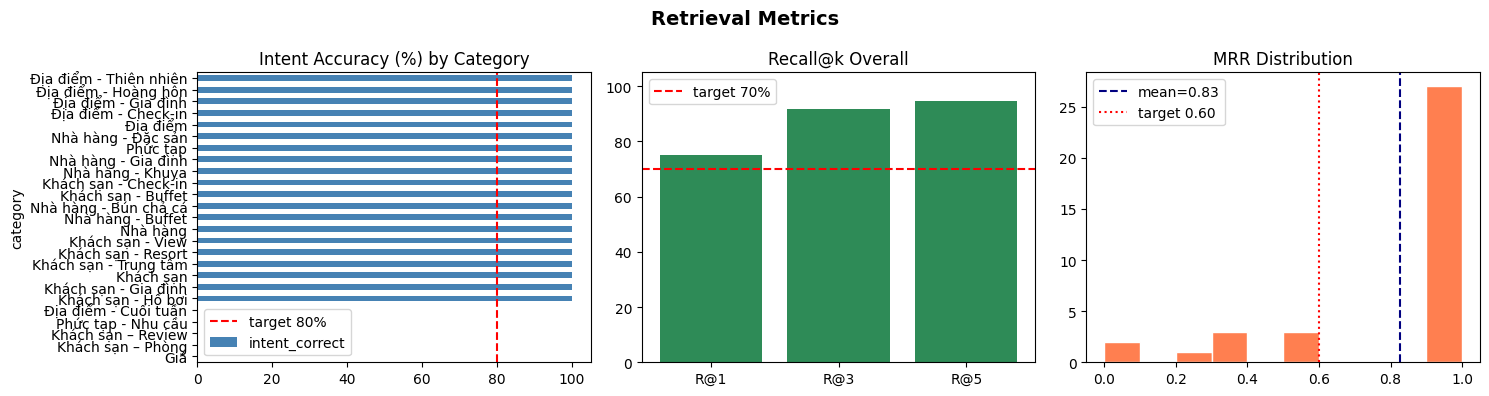

💾 Saved retrieval_metrics.png


In [13]:
# ── Biểu đồ Recall@k theo Category ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Retrieval Metrics", fontsize=14, fontweight="bold")

# 1. Intent Accuracy by category
cat_intent = df_ret.groupby("category")["intent_correct"].mean() * 100
cat_intent.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Intent Accuracy (%) by Category")
axes[0].axvline(80, color="red", linestyle="--", label="target 80%")
axes[0].legend()

# 2. Recall@k overall
recall_vals = [df_ret[f"recall@{k}"].mean() * 100 for k in K_VALUES]
axes[1].bar([f"R@{k}" for k in K_VALUES], recall_vals, color="seagreen")
axes[1].axhline(70, color="red", linestyle="--", label="target 70%")
axes[1].set_ylim(0, 105)
axes[1].set_title("Recall@k Overall")
axes[1].legend()

# 3. MRR distribution
axes[2].hist(df_ret["mrr"], bins=10, color="coral", edgecolor="white")
axes[2].axvline(df_ret["mrr"].mean(), color="navy", linestyle="--",
                label=f"mean={df_ret['mrr'].mean():.2f}")
axes[2].axvline(0.6, color="red", linestyle=":", label="target 0.60")
axes[2].set_title("MRR Distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/retrieval_metrics.png", dpi=150)
plt.show()
print("💾 Saved retrieval_metrics.png")

In [14]:
# ── 2A: Sinh câu trả lời + đo latency ─────────────────────────────────────
generation_rows = []

for item in tqdm(BENCHMARK, desc="Generation eval"):
    query    = item["query"]
    keywords = item["keywords"]
    gold     = item["gold_answer"]

    ans, latency = full_answer(query, top_k=5)
    answer_text  = ans.get("answer", "")
    n_results    = len(ans.get("docs", []))

    # ── Keyword Coverage Score ─────────────────────────────────────────────
    ans_lower = answer_text.lower()
    kw_hits   = sum(1 for kw in keywords if kw.lower() in ans_lower)
    kw_score  = kw_hits / len(keywords) if keywords else 0

    # ── Resolution (nâng cấp cho DanangGuide RAG) ──────────────────────────────

    # 1. Các cụm từ từ chối / không có thông tin (mở rộng theo system prompt của RAG)
    refuse_phrases = [
        # Từ chối gốc
        "xin lỗi", "tôi không biết", "không có thông tin",
        "tôi không chắc", "không tìm thấy",
        # Thêm: đặc thù của DanangGuide
        "chưa cập nhật thông tin",
        "hệ thống chưa có thông tin",
        "chưa có thông tin về",
        "hiện chưa có thông tin",
        "chỉ hỗ trợ tư vấn du lịch",   # out-of-scope response
        "không trả lời được",
        "nằm ngoài phạm vi",
    ]
    
    # 2. Các dấu hiệu câu trả lời CÓ NỘI DUNG THỰC (địa điểm, giá, địa chỉ...)
    positive_signals = [
        "địa chỉ", "mức giá", "đường ", "quận",
        "điểm nổi bật", "đánh giá", "rating",
        "vnd", "vnđ", "nghìn", "triệu",
        "khách sạn", "nhà hàng", "địa điểm",
        "ngày 1", "ngày 2",   # itinerary
        "★", "⭐", "🏨", "🍜", "🌍",  # emoji từ format của RAG
    ]
    
    has_refusal    = any(p in ans_lower for p in refuse_phrases)
    has_content    = any(s in ans_lower for s in positive_signals)
    has_min_length = len(answer_text.strip()) >= 80
    
    # Resolved = không từ chối VÀ có nội dung thực VÀ đủ dài
    is_resolved = (not has_refusal) and has_content and has_min_length
    
    # is_complete tách riêng để debug rõ hơn
    is_complete = has_min_length and has_content

    generation_rows.append({
    "id"            : item["id"],
    "category"      : item["category"],
    "query"         : query[:55] + "…" if len(query) > 55 else query,
    "answer"        : answer_text[:200],
    "kw_score"      : round(kw_score, 2),
    "is_resolved"   : is_resolved,
    "is_complete"   : is_complete,
    "has_refusal"   : has_refusal,    # cột debug: thấy từ chối không?
    "has_content"   : has_content,    # cột debug: có nội dung thực không?
    "n_results"     : n_results,
    "latency_total" : round(latency, 2),
})

df_gen = pd.DataFrame(generation_rows)
print(df_gen[["id", "category", "kw_score", "is_resolved", "is_complete", "latency_total"]].to_string(index=False))

Generation eval:   0%|          | 0/36 [00:00<?, ?it/s]


📥 Câu hỏi: Khách sạn nào ở Đà Nẵng có giá dưới 1 triệu đồng?

🔀 [Router] Phân loại câu hỏi...
   Intent: hotel_search | Needs RAG: True
   Lý do: Người dùng đang tìm kiếm chung khách sạn tại Đà Nẵng với điều kiện giá cả cụ thể

🔍 [Extractor] Trích xuất thông tin có cấu trúc...
   Entity:    []
   Semantic:  'khách sạn giá rẻ'
   Filters:   {'max_price': 1000000, 'price_level': 'mid'}

📚 [Retriever] Tìm kiếm vector với query: 'khách sạn giá rẻ'
   Tìm được 8 docs từ 3 collections

🏆 [Reranker] Xếp hạng lại 8 docs...
   Top docs sau rerank:
   - Hans Hotel | vector=0.577 | rerank=0.115
   - Paradise Hotel | vector=0.576 | rerank=0.141
   - Tuyet Son Hotel ( TS Ocean Hotel ) | vector=0.577 | rerank=0.101
   ⚠️  Rerank score thấp (0.115 < 0.3).

📝 [Context Builder] Ghép context + parent lookup...
   Context: 3790 ký tự | 4 docs (bao gồm parent)

🤖 [Synthesizer] Tổng hợp câu trả lời (thinking=OFF)...

──────────────────────────────────────────────────────────────────────
💬 Câu trả lời:
Chà

In [15]:
# ── 2B: LLM-as-a-Judge (DeepSeek via OpenRouter) ───────────────────────────────
# Yêu cầu biến môi trường: OPENROUTER_API_KEY_DEEPSEEK trong Kaggle Secrets

import requests
import json
import re
import time
import os

# Dùng Kaggle Secrets nếu có
def _kaggle_secret(key):
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret(key)
    except Exception:
        return os.getenv(key)

DEEPSEEK_KEY = _kaggle_secret("OPENROUTER_API_KEY_DEEPSEEK")

JUDGE_SCORES = {}   # id → {faithfulness, relevance, accuracy}

def judge_with_deepseek(prompt: str, api_key: str) -> dict:
    resp = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json",
        },
        json={
            "model": "deepseek/deepseek-chat-v3-0324",
            "messages": [{"role": "user", "content": prompt}],
            "max_tokens": 300,
        },
        timeout=30,
    )
    text = resp.json()["choices"][0]["message"]["content"].strip()
    text = re.sub(r"```json|```", "", text).strip()
    return json.loads(text)

if DEEPSEEK_KEY:
    print("✅ Using DeepSeek via OpenRouter for LLM-as-a-Judge")

    # Load prompt
    JUDGE_PROMPT = """Bạn là giám khảo đánh giá câu trả lời của chatbot du lịch Đà Nẵng.

Câu hỏi: {query}
Câu trả lời mẫu: {gold}
Câu trả lời của chatbot: {answer}

Hãy chấm điểm trên thang 1–5 cho 3 tiêu chí sau và trả về JSON duy nhất:
- faithfulness: câu trả lời có bịa thông tin không liên quan không? (5=hoàn toàn trung thực)
- relevance: câu trả lời có liên quan đến câu hỏi không? (5=rất liên quan)
- accuracy: thông tin có chính xác, đầy đủ không? (5=rất chính xác)

CHỈ trả về JSON, không giải thích thêm:
{{"faithfulness": <int>, "relevance": <int>, "accuracy": <int>}}"""

    # Vòng lặp đánh giá
    for item in tqdm(BENCHMARK, desc="LLM-as-a-Judge (DeepSeek)"):
        gen_row = next((r for r in generation_rows if r["id"] == item["id"]), None)
        if gen_row is None:
            continue

        prompt = JUDGE_PROMPT.format(
            query=item["query"],
            gold=item["gold_answer"],
            answer=gen_row["answer"],
        )

        try:
            scores = judge_with_deepseek(prompt, DEEPSEEK_KEY)
            JUDGE_SCORES[item["id"]] = scores
        except Exception as e:
            print(f"⚠️  {item['id']}: {e}")

    print(f"✅ LLM-as-a-Judge complete: {len(JUDGE_SCORES)} / {len(BENCHMARK)}")

else:
    print("⚠️ OPENROUTER_API_KEY_DEEPSEEK không tìm thấy → bỏ qua LLM-as-a-Judge.")
    print("   Thêm secret 'OPENROUTER_API_KEY_DEEPSEEK' trong Kaggle Secrets để bật DeepSeek.")

✅ Using DeepSeek via OpenRouter for LLM-as-a-Judge


LLM-as-a-Judge (DeepSeek):   0%|          | 0/36 [00:00<?, ?it/s]

⚠️  H04: Expecting value: line 1 column 17 (char 16)
✅ LLM-as-a-Judge complete: 35 / 36


In [16]:
# ── Gộp judge scores vào df_gen ───────────────────────────────────────────
for col in ["faithfulness", "relevance", "accuracy"]:
    df_gen[col] = df_gen["id"].map(
        lambda i: JUDGE_SCORES.get(i, {}).get(col, None)
    )

print("\n📊 Generation Results with Judge Scores:")
display_cols = ["id", "kw_score", "is_resolved", "is_complete",
                "faithfulness", "relevance", "accuracy", "latency_total"]
print(df_gen[display_cols].to_string(index=False))


📊 Generation Results with Judge Scores:
  id  kw_score  is_resolved  is_complete  faithfulness  relevance  accuracy  latency_total
 H01      1.00         True         True           4.0        5.0       4.0          60.56
 H02      1.00         True         True           5.0        2.0       3.0          52.28
 H03      1.00         True         True           3.0        4.0       3.0          66.78
 H04      1.00         True         True           NaN        NaN       NaN          62.05
 H05      0.67         True         True           5.0        5.0       4.0          45.01
 H06      1.00         True         True           4.0        5.0       4.0          36.22
 H07      1.00         True         True           5.0        5.0       3.0          66.78
 H08      1.00         True         True           4.0        5.0       4.0          63.36
 H09      1.00         True         True           3.0        4.0       3.0          58.87
 H10      1.00         True         True         

In [17]:
# ── Generation Summary ─────────────────────────────────────────────────────
summary_gen = {
    "Resolution Rate"       : f"{df_gen['is_resolved'].mean()*100:.1f}%",
    "Completeness Rate"     : f"{df_gen['is_complete'].mean()*100:.1f}%",
    "Avg Keyword Coverage"  : f"{df_gen['kw_score'].mean():.2f}",
    "Avg Total Latency"     : f"{df_gen['latency_total'].mean():.2f}s",
}

for col in ["faithfulness", "relevance", "accuracy"]:
    if df_gen[col].notna().any():
        summary_gen[f"Avg {col.capitalize()} (1–5)"] = f"{df_gen[col].mean():.2f}"

GEN_TARGETS = {
    "Resolution Rate"     : "≥ 85%",
    "Avg Faithfulness"    : "≥ 4.0/5",
    "Avg Relevance"       : "≥ 4.0/5",
    "Avg Accuracy"        : "≥ 3.8/5",
    "Avg Total Latency"   : "< 15s",
}

print("\n" + "="*60)
print("✍️  GENERATION QUALITY SUMMARY")
print("="*60)
rows_p = [[m, v, GEN_TARGETS.get(m, "—")] for m, v in summary_gen.items()]
print(tabulate(rows_p, headers=["Metric", "Score", "Target"], tablefmt="rounded_outline"))


✍️  GENERATION QUALITY SUMMARY
╭────────────────────────┬─────────┬──────────╮
│ Metric                 │ Score   │ Target   │
├────────────────────────┼─────────┼──────────┤
│ Resolution Rate        │ 100.0%  │ ≥ 85%    │
│ Completeness Rate      │ 100.0%  │ —        │
│ Avg Keyword Coverage   │ 0.94    │ —        │
│ Avg Total Latency      │ 67.95s  │ < 15s    │
│ Avg Faithfulness (1–5) │ 4.49    │ —        │
│ Avg Relevance (1–5)    │ 4.17    │ —        │
│ Avg Accuracy (1–5)     │ 3.20    │ —        │
╰────────────────────────┴─────────┴──────────╯


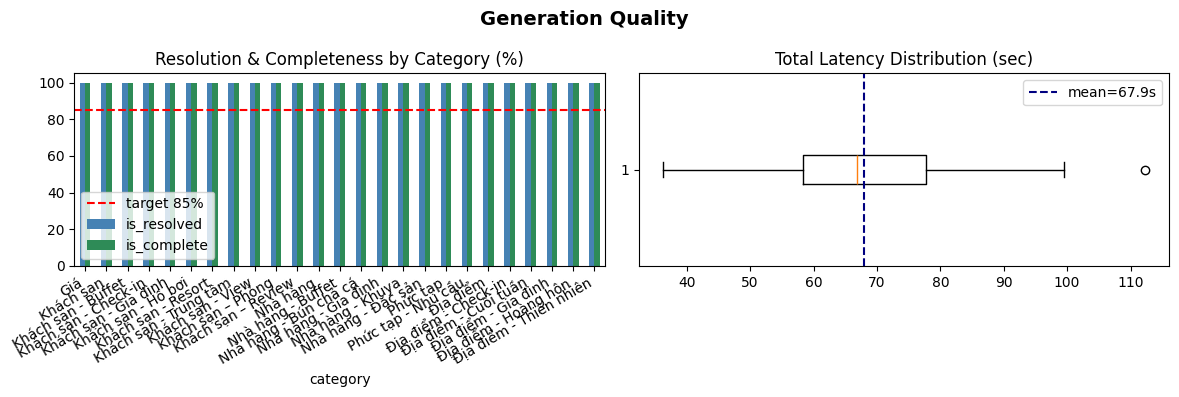

In [18]:
# ── Biểu đồ Generation ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Generation Quality", fontsize=14, fontweight="bold")

# 1. Resolution & Completeness by category
cat_res = df_gen.groupby("category")[["is_resolved", "is_complete"]].mean() * 100
cat_res.plot(kind="bar", ax=axes[0], color=["steelblue", "seagreen"])
axes[0].set_title("Resolution & Completeness by Category (%)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
axes[0].axhline(85, color="red", linestyle="--", label="target 85%")
axes[0].legend()

# 2. Latency distribution
axes[1].boxplot(df_gen["latency_total"].dropna(), vert=False)
axes[1].axvline(df_gen["latency_total"].mean(), color="navy",
                linestyle="--", label=f"mean={df_gen['latency_total'].mean():.1f}s")
axes[1].set_title("Total Latency Distribution (sec)")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/generation_metrics.png", dpi=150)
plt.show()

In [19]:
# ── Latency Breakdown ─────────────────────────────────────────────────────
# df_ret chứa latency_retrieval, df_gen chứa latency_total
df_perf = df_ret[["id", "latency_retrieval"]].merge(
    df_gen[["id", "latency_total"]], on="id", how="left"
)
df_perf["latency_generation"] = (df_perf["latency_total"] - df_perf["latency_retrieval"]).clip(lower=0)

perf_summary = {
    "Avg Retrieval Latency"  : f"{df_perf['latency_retrieval'].mean():.2f}s",
    "Avg Generation Latency" : f"{df_perf['latency_generation'].mean():.2f}s",
    "Avg Total Latency"      : f"{df_perf['latency_total'].mean():.2f}s",
    "P95 Total Latency"      : f"{df_perf['latency_total'].quantile(0.95):.2f}s",
    "Max Total Latency"      : f"{df_perf['latency_total'].max():.2f}s",
}

print("\n" + "="*60)
print("⚙️  SYSTEM PERFORMANCE SUMMARY")
print("="*60)
PERF_TARGETS = {
    "Avg Retrieval Latency" : "< 2.0s",
    "Avg Total Latency"     : "< 15s (local LLM)",
    "P95 Total Latency"     : "< 20s",
}
rows_p2 = [[m, v, PERF_TARGETS.get(m, "—")] for m, v in perf_summary.items()]
print(tabulate(rows_p2, headers=["Metric", "Value", "Target"], tablefmt="rounded_outline"))


⚙️  SYSTEM PERFORMANCE SUMMARY
╭────────────────────────┬─────────┬───────────────────╮
│ Metric                 │ Value   │ Target            │
├────────────────────────┼─────────┼───────────────────┤
│ Avg Retrieval Latency  │ 68.21s  │ < 2.0s            │
│ Avg Generation Latency │ 3.28s   │ —                 │
│ Avg Total Latency      │ 67.95s  │ < 15s (local LLM) │
│ P95 Total Latency      │ 90.46s  │ < 20s             │
│ Max Total Latency      │ 112.30s │ —                 │
╰────────────────────────┴─────────┴───────────────────╯


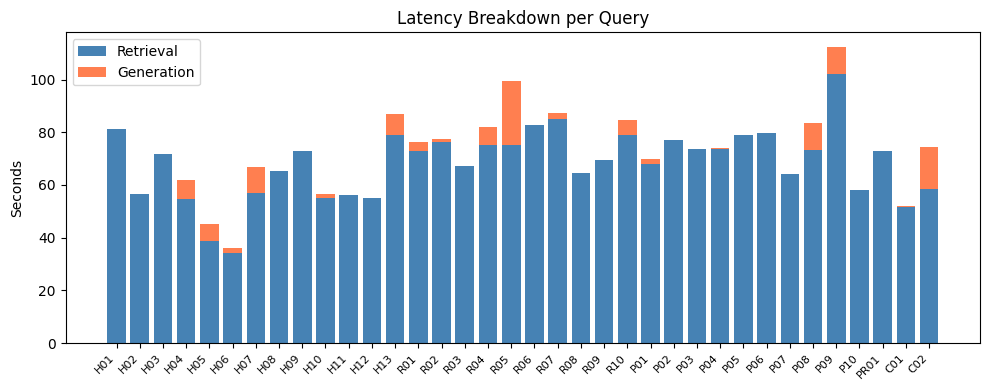

In [20]:
# ── Biểu đồ Latency Breakdown ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

x = range(len(df_perf))
ax.bar(x, df_perf["latency_retrieval"], label="Retrieval", color="steelblue")
ax.bar(x, df_perf["latency_generation"],
       bottom=df_perf["latency_retrieval"],
       label="Generation", color="coral")

ax.set_xticks(list(x))
ax.set_xticklabels(df_perf["id"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Seconds")
ax.set_title("Latency Breakdown per Query")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/latency_breakdown.png", dpi=150)
plt.show()

In [21]:
# ── Gộp tất cả vào master dataframe ───────────────────────────────────────
df_master = df_ret.merge(df_gen, on="id", how="left", suffixes=("", "_gen"))
df_master.head()
df_master.dtypes

id                    object
category              object
query                 object
expected_intent       object
detected_intent       object
intent_correct          bool
n_retrieved            int64
latency_retrieval    float64
recall@1               int64
precision@1          float64
recall@3               int64
precision@3          float64
recall@5               int64
precision@5          float64
mrr                  float64
category_gen          object
query_gen             object
answer                object
kw_score             float64
is_resolved             bool
is_complete             bool
has_refusal             bool
has_content             bool
n_results              int64
latency_total        float64
faithfulness         float64
relevance            float64
accuracy             float64
dtype: object

In [22]:
score_cols = ["intent_correct", "recall@5", "kw_score", "is_resolved", "is_complete"]

# 1. Convert boolean → numeric
bool_cols = ["intent_correct", "is_resolved", "is_complete"]
for col in bool_cols:
    if col in df_master.columns:
        df_master[col] = df_master[col].astype("float64")  # True->1.0, False->0.0

# 2. Convert fully numeric cols
num_cols = ["recall@5", "kw_score"]
for col in num_cols:
    if col in df_master.columns:
        df_master[col] = pd.to_numeric(df_master[col], errors="coerce")

# 3. Debug xem còn object không
print(df_master[score_cols].dtypes)
print(df_master[score_cols].head())

# 4. Compute overall score
df_master["overall_score"] = df_master[score_cols].mean(axis=1).round(2)

print("\n🏆 PER-QUERY LEADERBOARD (sorted by overall_score)")
display_cols = [
    "id", 
    "category_gen" if "category_gen" in df_master.columns else "category",
    "intent_correct", "recall@5", "kw_score",
    "is_resolved", "latency_total", "overall_score"
]
display_cols = [c for c in display_cols if c in df_master.columns]

print(df_master[display_cols].sort_values("overall_score", ascending=False).to_string(index=False))

intent_correct    float64
recall@5            int64
kw_score          float64
is_resolved       float64
is_complete       float64
dtype: object
   intent_correct  recall@5  kw_score  is_resolved  is_complete
0             1.0         1      1.00          1.0          1.0
1             1.0         1      1.00          1.0          1.0
2             1.0         1      1.00          1.0          1.0
3             1.0         1      1.00          1.0          1.0
4             0.0         0      0.67          1.0          1.0

🏆 PER-QUERY LEADERBOARD (sorted by overall_score)
  id           category_gen  intent_correct  recall@5  kw_score  is_resolved  latency_total  overall_score
 H01              Khách sạn             1.0         1      1.00          1.0          60.56           1.00
 H02              Khách sạn             1.0         1      1.00          1.0          52.28           1.00
 H03              Khách sạn             1.0         1      1.00          1.0          66.78         

In [23]:
# ── Final Report Card ────────────────────────────────────────────────────
all_summaries = [
    # [Group, Metric, Score, Target, Pass?]
    ["Retrieval", "Intent Accuracy",
     f"{df_ret['intent_correct'].mean()*100:.1f}%", "≥ 80%",
     "✅" if df_ret["intent_correct"].mean() >= 0.8 else "❌"],

    ["Retrieval", "MRR",
     f"{df_ret['mrr'].mean():.3f}", "≥ 0.60",
     "✅" if df_ret["mrr"].mean() >= 0.6 else "❌"],

    ["Retrieval", "Recall@5",
     f"{df_ret['recall@5'].mean()*100:.1f}%", "≥ 70%",
     "✅" if df_ret["recall@5"].mean() >= 0.7 else "❌"],

    ["Generation", "Resolution Rate",
     f"{df_gen['is_resolved'].mean()*100:.1f}%", "≥ 85%",
     "✅" if df_gen["is_resolved"].mean() >= 0.85 else "❌"],

    ["Generation", "Keyword Coverage",
     f"{df_gen['kw_score'].mean():.2f}", "≥ 0.70",
     "✅" if df_gen["kw_score"].mean() >= 0.7 else "❌"],
]

# Add judge scores if available
if df_gen["faithfulness"].notna().any():
    all_summaries += [
        ["Generation", "Faithfulness (1–5)",
         f"{df_gen['faithfulness'].mean():.2f}", "≥ 4.0",
         "✅" if df_gen["faithfulness"].mean() >= 4.0 else "❌"],
        ["Generation", "Relevance (1–5)",
         f"{df_gen['relevance'].mean():.2f}", "≥ 4.0",
         "✅" if df_gen["relevance"].mean() >= 4.0 else "❌"],
        ["Generation", "Accuracy (1–5)",
         f"{df_gen['accuracy'].mean():.2f}", "≥ 3.8",
         "✅" if df_gen["accuracy"].mean() >= 3.8 else "❌"],
    ]

all_summaries += [
    ["System", "Avg Retrieval Latency",
     f"{df_perf['latency_retrieval'].mean():.2f}s", "< 2.0s",
     "✅" if df_perf["latency_retrieval"].mean() < 2.0 else "❌"],

    ["System", "Avg Total Latency",
     f"{df_perf['latency_total'].mean():.2f}s", "< 15s",
     "✅" if df_perf["latency_total"].mean() < 15 else "❌"],
]

print("\n" + "="*70)
print("🏅  FINAL REPORT CARD — RAG Chatbot Du Lịch Đà Nẵng")
print("="*70)
print(tabulate(all_summaries,
               headers=["Group", "Metric", "Score", "Target", "Pass"],
               tablefmt="rounded_outline"))

n_pass = sum(1 for r in all_summaries if r[4] == "✅")
print(f"\n📊 Passed: {n_pass}/{len(all_summaries)} metrics")


🏅  FINAL REPORT CARD — RAG Chatbot Du Lịch Đà Nẵng
╭────────────┬───────────────────────┬─────────┬──────────┬────────╮
│ Group      │ Metric                │ Score   │ Target   │ Pass   │
├────────────┼───────────────────────┼─────────┼──────────┼────────┤
│ Retrieval  │ Intent Accuracy       │ 86.1%   │ ≥ 80%    │ ✅     │
│ Retrieval  │ MRR                   │ 0.826   │ ≥ 0.60   │ ✅     │
│ Retrieval  │ Recall@5              │ 94.4%   │ ≥ 70%    │ ✅     │
│ Generation │ Resolution Rate       │ 100.0%  │ ≥ 85%    │ ✅     │
│ Generation │ Keyword Coverage      │ 0.94    │ ≥ 0.70   │ ✅     │
│ Generation │ Faithfulness (1–5)    │ 4.49    │ ≥ 4.0    │ ✅     │
│ Generation │ Relevance (1–5)       │ 4.17    │ ≥ 4.0    │ ✅     │
│ Generation │ Accuracy (1–5)        │ 3.20    │ ≥ 3.8    │ ❌     │
│ System     │ Avg Retrieval Latency │ 68.21s  │ < 2.0s   │ ❌     │
│ System     │ Avg Total Latency     │ 67.95s  │ < 15s    │ ❌     │
╰────────────┴───────────────────────┴─────────┴──────────┴──

In [24]:
# ── Lưu kết quả ra CSV ───────────────────────────────────────────────────
df_ret.to_csv("/kaggle/working/eval_retrieval.csv", index=False)
df_gen.to_csv("/kaggle/working/eval_generation.csv", index=False)
df_master.to_csv("/kaggle/working/eval_master.csv", index=False)

# Lưu report card
df_report = pd.DataFrame(all_summaries, columns=["Group", "Metric", "Score", "Target", "Pass"])
df_report.to_csv("/kaggle/working/eval_report_card.csv", index=False)

print("✅ Files saved:")
print("   /kaggle/working/eval_retrieval.csv")
print("   /kaggle/working/eval_generation.csv")
print("   /kaggle/working/eval_master.csv")
print("   /kaggle/working/eval_report_card.csv")
print("   /kaggle/working/retrieval_metrics.png")
print("   /kaggle/working/generation_metrics.png")
print("   /kaggle/working/latency_breakdown.png")

✅ Files saved:
   /kaggle/working/eval_retrieval.csv
   /kaggle/working/eval_generation.csv
   /kaggle/working/eval_master.csv
   /kaggle/working/eval_report_card.csv
   /kaggle/working/retrieval_metrics.png
   /kaggle/working/generation_metrics.png
   /kaggle/working/latency_breakdown.png


In [25]:
# ============================================
# CELL B: Đánh giá chuyên biệt cho câu hỏi Lịch trình (Itinerary Evaluation)
# ============================================
# Chạy cell này SAU khi đã chạy xong retrieval eval và generation eval cho BENCHMARK_FULL.
# Yêu cầu: biến `pipeline` và `full_answer` đã được định nghĩa ở Cell 6.
 
import re, time
from tqdm.auto import tqdm
 
# ────────────────────────────────────────────────────────────────────────────
# PHẦN 1: STRUCTURE EVALUATOR (Đánh giá cấu trúc câu trả lời)
# ────────────────────────────────────────────────────────────────────────────
 
class ItineraryStructureEvaluator:
    """
    Đánh giá cấu trúc câu trả lời lịch trình KHÔNG dùng LLM.
    Sử dụng heuristics + regex — nhanh và không tốn token.
    """
 
    # ── Patterns ──────────────────────────────────────────────────────────
    DAY_PATTERNS = [
        r"ngày\s*\d+",
        r"day\s*\d+",
        r"buổi\s*(sáng|trưa|chiều|tối)",
        r"\*\*ngày\s*\d+\*\*",
        r"📅",
    ]
 
    HOTEL_KEYWORDS   = ["khách sạn", "resort", "nhà nghỉ", "homestay", "check-in", "lưu trú", "phòng"]
    FOOD_KEYWORDS    = ["ăn", "nhà hàng", "quán", "hải sản", "mì quảng", "bún", "bánh", "buffet", "đặc sản", "ẩm thực"]
    ATTRACTION_KWORDS = ["tham quan", "biển", "cầu", "chùa", "công viên", "bán đảo", "núi", "bảo tàng", "đèo", "hội an"]
    HALLUCINATION_KW  = ["hà nội", "hồ chí minh", "sài gòn", "đà lạt", "nha trang", "phú quốc"]  # Thành phố không liên quan
 
    def evaluate(self, answer: str, criteria: dict) -> dict:
        ans = answer.lower()
 
        # 1. Cấu trúc theo ngày
        day_hits = sum(1 for p in self.DAY_PATTERNS if re.search(p, ans))
        has_daily_structure = day_hits >= 1
 
        # 2. Đếm số ngày được đề cập
        day_numbers = re.findall(r"ngày\s*(\d+)", ans)
        days_mentioned = max((int(d) for d in day_numbers), default=0) if day_numbers else 0
 
        # 3. Kiểm tra các thành phần
        has_hotel      = any(kw in ans for kw in self.HOTEL_KEYWORDS)
        has_food       = any(kw in ans for kw in self.FOOD_KEYWORDS)
        has_attractions = any(kw in ans for kw in self.ATTRACTION_KWORDS)
 
        # 4. Kiểm tra ảo giác (đề cập thành phố khác)
        hallucination_hits = [kw for kw in self.HALLUCINATION_KW if kw in ans]
        has_hallucination  = len(hallucination_hits) > 0
 
        # 5. Kiểm tra độ đầy đủ
        min_days_req  = criteria.get("min_days_mentioned", 1)
        days_ok       = days_mentioned >= min_days_req or not criteria.get("has_daily_structure", True)
        hotel_ok      = has_hotel      if criteria.get("has_hotel", True)       else True
        food_ok       = has_food       if criteria.get("has_food", True)        else True
        attract_ok    = has_attractions if criteria.get("has_attractions", True) else True
        structure_ok  = has_daily_structure if criteria.get("has_daily_structure", True) else True
 
        # 6. Tính điểm thành phần (0–1 mỗi chiều)
        component_scores = {
            "structure": 1.0 if structure_ok  else 0.0,
            "days"     : min(1.0, days_mentioned / max(min_days_req, 1)),
            "hotel"    : 1.0 if hotel_ok      else 0.0,
            "food"     : 1.0 if food_ok        else 0.0,
            "attractions": 1.0 if attract_ok  else 0.0,
            "no_hallucination": 0.0 if has_hallucination else 1.0,
        }
 
        # Trọng số: hallucination bị phạt nặng nhất
        weights = {
            "structure": 0.20,
            "days"     : 0.20,
            "hotel"    : 0.15,
            "food"     : 0.15,
            "attractions": 0.15,
            "no_hallucination": 0.15,
        }
 
        overall = sum(component_scores[k] * weights[k] for k in weights)
 
        return {
            "has_daily_structure": has_daily_structure,
            "days_mentioned"     : days_mentioned,
            "has_hotel"          : has_hotel,
            "has_food"           : has_food,
            "has_attractions"    : has_attractions,
            "hallucination_hits" : hallucination_hits,
            "component_scores"   : component_scores,
            "itinerary_score"    : round(overall, 3),  # 0.0 – 1.0
        }

In [26]:
# ────────────────────────────────────────────────────────────────────────────
# PHẦN 2: CHẠY EVALUATION
# ────────────────────────────────────────────────────────────────────────────
 
struct_eval = ItineraryStructureEvaluator()
itinerary_rows = []
 
print("🚀 Đang chạy Itinerary Evaluation...")
for item in tqdm(BENCHMARK_ITINERARY, desc="Itinerary eval"):
    t0 = time.perf_counter()
    ans_dict, latency = full_answer(item["query"], top_k=5)
    answer_text = ans_dict.get("answer", "")
    n_results   = len(ans.get("docs", []))
    context_info = ans_dict.get("analysis_context", {})
 
    # ── Structure evaluation ───────────────────────────────────────────────
    struct_result = struct_eval.evaluate(answer_text, item.get("eval_criteria", {}))
 
    # ── Keyword coverage ──────────────────────────────────────────────────
    ans_lower = answer_text.lower()
    kw_hits   = sum(1 for kw in item["keywords"] if kw.lower() in ans_lower)
    kw_score  = round(kw_hits / len(item["keywords"]), 2) if item["keywords"] else 0.0
 
    # ── Resolution ────────────────────────────────────────────────────────
    refuse_phrases = ["xin lỗi", "không có thông tin", "tôi không biết", "không tìm thấy"]
    is_resolved    = not any(p in ans_lower for p in refuse_phrases)
 
    # ── Intent correct ────────────────────────────────────────────────────
    detected = context_info.get("intent")
    if hasattr(detected, "value"):
        detected = detected.value
    intent_correct = (str(detected) == item["expected_intent"])
 
    row = {
        "id"               : item["id"],
        "category"         : item["category"],
        "query"            : item["query"][:60] + "…" if len(item["query"]) > 60 else item["query"],
        "intent_correct"   : intent_correct,
        "detected_intent"  : detected,
        "n_results"        : n_results,
        "kw_score"         : kw_score,
        "is_resolved"      : is_resolved,
        # Structure sub-scores
        "has_daily_structure": struct_result["has_daily_structure"],
        "days_mentioned"     : struct_result["days_mentioned"],
        "has_hotel"          : struct_result["has_hotel"],
        "has_food"           : struct_result["has_food"],
        "has_attractions"    : struct_result["has_attractions"],
        "no_hallucination"   : len(struct_result["hallucination_hits"]) == 0,
        "itinerary_score"    : struct_result["itinerary_score"],
        "latency"            : round(latency, 2),
        "answer_preview"     : answer_text[:300],
    }
    itinerary_rows.append(row)
 
df_itin = pd.DataFrame(itinerary_rows)

🚀 Đang chạy Itinerary Evaluation...


Itinerary eval:   0%|          | 0/10 [00:00<?, ?it/s]


📥 Câu hỏi: Cho tôi kế hoạch du lịch Đà Nẵng 3 ngày 2 đêm

🔀 [Router] Phân loại câu hỏi...
   Intent: itinerary_search | Needs RAG: True
   Lý do: Yêu cầu lập lịch trình tổng hợp cho chuyến đi Đà Nẵng

🔍 [Extractor] Trích xuất thông tin có cấu trúc...
   Entity:    []
   Semantic:  'kế hoạch du lịch 3 ngày 2 đêm'
   Filters:   {'visit_duration': ['3 ngày 2 đêm']}

📚 [Itinerary Mode] Phân luồng tìm kiếm song song...
   🎭 Query vui chơi: 'địa điểm du lịch vui chơi tham quan kế hoạch du lịch 3 ngày 2 đêm'
   🍜 Query ăn uống: 'nhà hàng quán ăn đặc sản ngon kế hoạch du lịch 3 ngày 2 đêm'
   🏨 Query lưu trú: 'khách sạn homestay resort lưu trú kế hoạch du lịch 3 ngày 2 đêm'
   Top docs sau rerank:
   - Bãi biển Mỹ Khê | vector=0.486 | rerank=0.526
   - Cầu Sông Hàn & Cầu Tình Yêu | vector=0.512 | rerank=0.451
   - Helio Center & Bubble Park | vector=0.507 | rerank=0.449

📝 [Context Builder] Ghép context + parent lookup...
   Context: 3220 ký tự | 5 docs (bao gồm parent)

🤖 [Synthesizer] Tổng 

In [27]:
# ────────────────────────────────────────────────────────────────────────────
# PHẦN 3: HIỂN THỊ KẾT QUẢ
# ────────────────────────────────────────────────────────────────────────────
 
print("\n" + "="*70)
print("🗺️  ITINERARY EVALUATION — Per-Query Results")
print("="*70)
display_cols = [
    "id", "intent_correct", "kw_score", "is_resolved",
    "has_daily_structure", "days_mentioned",
    "has_hotel", "has_food", "has_attractions",
    "no_hallucination", "itinerary_score", "latency",
]
print(df_itin[display_cols].to_string(index=False))
 
# ── Summary ──────────────────────────────────────────────────────────────────
ITIN_TARGETS = {
    "Intent Accuracy"       : ("≥ 90%",  lambda: df_itin["intent_correct"].mean() >= 0.90),
    "Itinerary Score"       : ("≥ 0.70", lambda: df_itin["itinerary_score"].mean() >= 0.70),
    "Keyword Coverage"      : ("≥ 0.60", lambda: df_itin["kw_score"].mean() >= 0.60),
    "Resolution Rate"       : ("≥ 85%",  lambda: df_itin["is_resolved"].mean() >= 0.85),
    "Has Daily Structure"   : ("≥ 80%",  lambda: df_itin["has_daily_structure"].mean() >= 0.80),
    "Has Hotel Mention"     : ("≥ 70%",  lambda: df_itin["has_hotel"].mean() >= 0.70),
    "Has Food Mention"      : ("≥ 90%",  lambda: df_itin["has_food"].mean() >= 0.90),
    "Has Attraction Mention": ("≥ 90%",  lambda: df_itin["has_attractions"].mean() >= 0.90),
    "No Hallucination"      : ("= 100%", lambda: df_itin["no_hallucination"].mean() >= 1.00),
    "Avg Latency"           : ("< 20s",  lambda: df_itin["latency"].mean() < 20),
}
 
summary_rows = []
for metric, (target, check_fn) in ITIN_TARGETS.items():
    col_map = {
        "Intent Accuracy"       : ("intent_correct",    lambda v: f"{v*100:.1f}%"),
        "Itinerary Score"       : ("itinerary_score",   lambda v: f"{v:.3f}"),
        "Keyword Coverage"      : ("kw_score",          lambda v: f"{v:.2f}"),
        "Resolution Rate"       : ("is_resolved",       lambda v: f"{v*100:.1f}%"),
        "Has Daily Structure"   : ("has_daily_structure", lambda v: f"{v*100:.1f}%"),
        "Has Hotel Mention"     : ("has_hotel",         lambda v: f"{v*100:.1f}%"),
        "Has Food Mention"      : ("has_food",          lambda v: f"{v*100:.1f}%"),
        "Has Attraction Mention": ("has_attractions",   lambda v: f"{v*100:.1f}%"),
        "No Hallucination"      : ("no_hallucination",  lambda v: f"{v*100:.1f}%"),
        "Avg Latency"           : ("latency",           lambda v: f"{v:.2f}s"),
    }
    col, fmt = col_map[metric]
    raw_val = df_itin[col].mean() if col in df_itin.columns else 0
    score_str = fmt(raw_val)
    passed    = "✅" if check_fn() else "❌"
    summary_rows.append([metric, score_str, target, passed])
 
print("\n" + "="*70)
print("🗺️  ITINERARY QUALITY SUMMARY")
print("="*70)
print(tabulate(summary_rows,
               headers=["Metric", "Score", "Target", "Pass"],
               tablefmt="rounded_outline"))
 
n_pass_itin = sum(1 for r in summary_rows if r[3] == "✅")
print(f"\n📊 Passed: {n_pass_itin}/{len(ITIN_TARGETS)} itinerary metrics")


🗺️  ITINERARY EVALUATION — Per-Query Results
  id  intent_correct  kw_score  is_resolved  has_daily_structure  days_mentioned  has_hotel  has_food  has_attractions  no_hallucination  itinerary_score  latency
IT01           False      1.00         True                 True               3       True      True             True              True              1.0   125.82
IT02           False      0.67         True                 True               2       True      True             True              True              1.0   106.58
IT03           False      1.00         True                 True               4       True      True             True              True              1.0   163.45
IT04           False      1.00         True                 True               3       True      True             True              True              1.0   128.73
IT05           False      0.75         True                 True               3       True      True             True              True   

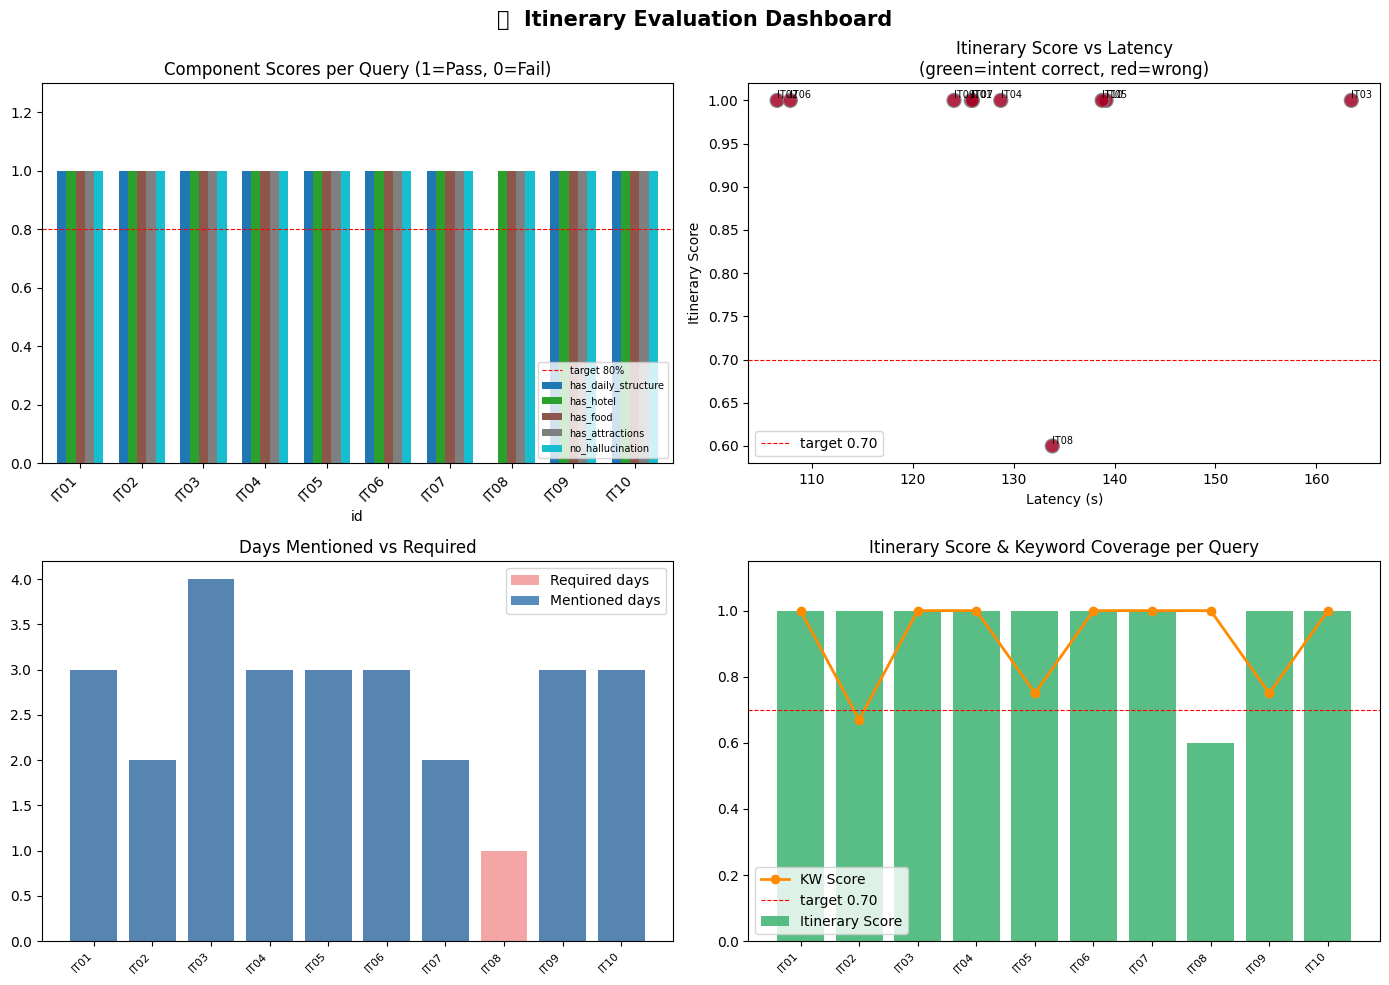

💾 Saved: /kaggle/working/itinerary_eval_dashboard.png


In [28]:
# ────────────────────────────────────────────────────────────────────────────
# PHẦN 4: BIỂU ĐỒ CHUYÊN BIỆT CHO LỊCH TRÌNH
# ────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("🗺️  Itinerary Evaluation Dashboard", fontsize=15, fontweight="bold")
 
# 1. Radar-style bar — Component scores per query
comp_cols = ["has_daily_structure", "has_hotel", "has_food", "has_attractions", "no_hallucination"]
comp_df   = df_itin[["id"] + comp_cols].set_index("id").astype(float)
comp_df.plot(kind="bar", ax=axes[0, 0], colormap="tab10", width=0.75)
axes[0, 0].set_title("Component Scores per Query (1=Pass, 0=Fail)")
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha="right")
axes[0, 0].axhline(0.8, color="red", linestyle="--", linewidth=0.8, label="target 80%")
axes[0, 0].legend(loc="lower right", fontsize=7)
axes[0, 0].set_ylim(0, 1.3)
 
# 2. Itinerary Score vs Latency scatter
axes[0, 1].scatter(
    df_itin["latency"], df_itin["itinerary_score"],
    c=df_itin["intent_correct"].astype(float),
    cmap="RdYlGn", s=100, edgecolors="grey", alpha=0.85
)
for _, row in df_itin.iterrows():
    axes[0, 1].annotate(row["id"], (row["latency"], row["itinerary_score"]),
                        fontsize=7, ha="left", va="bottom")
axes[0, 1].set_xlabel("Latency (s)")
axes[0, 1].set_ylabel("Itinerary Score")
axes[0, 1].set_title("Itinerary Score vs Latency\n(green=intent correct, red=wrong)")
axes[0, 1].axhline(0.70, color="red", linestyle="--", linewidth=0.8, label="target 0.70")
axes[0, 1].legend()
 
# 3. Days mentioned vs Min days required
min_days_req = [item["eval_criteria"].get("min_days_mentioned", 1) for item in BENCHMARK_ITINERARY]
x_idx = range(len(df_itin))
axes[1, 0].bar(x_idx, min_days_req, color="lightcoral", label="Required days", alpha=0.7)
axes[1, 0].bar(x_idx, df_itin["days_mentioned"], color="steelblue", label="Mentioned days", alpha=0.9)
axes[1, 0].set_xticks(list(x_idx))
axes[1, 0].set_xticklabels(df_itin["id"], rotation=45, ha="right", fontsize=8)
axes[1, 0].set_title("Days Mentioned vs Required")
axes[1, 0].legend()
 
# 4. Overall itinerary score distribution + KW score
axes[1, 1].bar(df_itin["id"], df_itin["itinerary_score"],
               color="mediumseagreen", label="Itinerary Score", alpha=0.85)
axes[1, 1].plot(df_itin["id"], df_itin["kw_score"],
                color="darkorange", marker="o", linewidth=2, label="KW Score")
axes[1, 1].axhline(0.70, color="red", linestyle="--", linewidth=0.8, label="target 0.70")
axes[1, 1].set_xticklabels(df_itin["id"], rotation=45, ha="right", fontsize=8)
axes[1, 1].set_ylim(0, 1.15)
axes[1, 1].set_title("Itinerary Score & Keyword Coverage per Query")
axes[1, 1].legend()
 
plt.tight_layout()
plt.savefig("/kaggle/working/itinerary_eval_dashboard.png", dpi=150)
plt.show()
print("💾 Saved: /kaggle/working/itinerary_eval_dashboard.png")

In [29]:
# ────────────────────────────────────────────────────────────────────────────
# PHẦN 5: LLM-as-a-Judge CHO LỊCH TRÌNH (Nếu có DEEPSEEK_KEY)
# ────────────────────────────────────────────────────────────────────────────
 
ITIN_JUDGE_SCORES = {}
 
ITIN_JUDGE_PROMPT = """
Bạn là chuyên gia đánh giá chatbot lập lịch trình du lịch Đà Nẵng.

Câu hỏi:
{query}

Câu trả lời mẫu:
{gold}

Câu trả lời chatbot:
{answer}

Hãy chấm điểm từ 1–5 cho các tiêu chí:

- coherence:
  Thứ tự các hoạt động có logic và mạch lạc không?

- coverage:
  Lịch trình có bao quát đầy đủ các hoạt động cần thiết
  cho toàn bộ chuyến đi không?

- feasibility:
  Lịch trình có khả thi thực tế về thời gian,
  khoảng cách và khối lượng hoạt động không?

- personalization:
  Lịch trình có đáp ứng nhu cầu hoặc sở thích
  được nêu trong câu hỏi không?

- local_relevance:
  Có sử dụng các địa điểm, nhà hàng,
  khách sạn thực tế tại Đà Nẵng không?

Trả về DUY NHẤT JSON:

{{
  "coherence": <1-5>,
  "coverage": <1-5>,
  "feasibility": <1-5>,
  "personalization": <1-5>,
  "local_relevance": <1-5>
}}
"""

DEEPSEEK_KEY = _kaggle_secret("OPENROUTER_API_KEY_DEEPSEEK")

if DEEPSEEK_KEY:
    print("\n🤖 Chạy LLM-as-a-Judge cho Itinerary queries...")

    from openrouter import OpenRouter

    with OpenRouter(api_key=DEEPSEEK_KEY) as or_client:

        for item in tqdm(BENCHMARK_ITINERARY, desc="Itinerary Judge"):

            gen_row = next(
                (r for r in itinerary_rows if r["id"] == item["id"]),
                None
            )

            if gen_row is None:
                continue

            prompt = ITIN_JUDGE_PROMPT.format(
                query=item["query"],
                gold=item["gold_answer"],
                answer=gen_row["answer_preview"],
            )

            try:
                resp = or_client.chat.send(
                    model="deepseek/deepseek-chat-v3-0324",
                    messages=[
                        {
                            "role": "user",
                            "content": prompt
                        }
                    ],
                    max_tokens=300,
                )

                raw = resp.choices[0].message.content.strip()

                raw = re.sub(r"```json|```", "", raw).strip()

                ITIN_JUDGE_SCORES[item["id"]] = json.loads(raw)

            except Exception as e:
                print(f"⚠️ {item['id']}: {e}")

    print(
        f"✅ Itinerary Judge: "
        f"{len(ITIN_JUDGE_SCORES)}/{len(BENCHMARK_ITINERARY)}"
    )

    # ------------------------------------------------------------------
    # Gộp điểm Judge vào DataFrame
    # ------------------------------------------------------------------

    judge_metrics = [
        "coherence",
        "coverage",
        "feasibility",
        "personalization",
        "local_relevance"
    ]

    for col in judge_metrics:
        df_itin[col] = df_itin["id"].map(
            lambda i: ITIN_JUDGE_SCORES.get(i, {}).get(col)
        )

    print("\n📊 Detailed Judge Scores")

    display_cols = [
        "id",
        "coherence",
        "coverage",
        "feasibility",
        "personalization",
        "local_relevance"
    ]

    print(df_itin[display_cols].to_string(index=False))

    # ------------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------------

    TARGETS = {
        "coherence": 4.0,
        "coverage": 4.0,
        "feasibility": 3.8,
        "personalization": 3.8,
        "local_relevance": 4.2,
    }

    judge_summary = []

    for metric, target in TARGETS.items():

        if metric not in df_itin.columns:
            continue

        if not df_itin[metric].notna().any():
            continue

        mean_val = df_itin[metric].mean()

        judge_summary.append([
            metric.replace("_", " ").title(),
            f"{mean_val:.2f}",
            f"≥ {target:.1f}",
            "✅" if mean_val >= target else "❌"
        ])

    print("\n" + "=" * 75)
    print("🤖 ITINERARY LLM-as-a-Judge SUMMARY")
    print("=" * 75)

    print(
        tabulate(
            judge_summary,
            headers=["Metric", "Score", "Target", "Pass"],
            tablefmt="rounded_outline"
        )
    )

else:
    print(
        "ℹ️ Bỏ qua LLM-as-a-Judge "
        "(không có DEEPSEEK_KEY). "
        "Chỉ dùng structure evaluation."
    )


🤖 Chạy LLM-as-a-Judge cho Itinerary queries...


Itinerary Judge:   0%|          | 0/10 [00:00<?, ?it/s]

⚠️ IT09: Expecting value: line 1 column 1 (char 0)
✅ Itinerary Judge: 9/10

📊 Detailed Judge Scores
  id  coherence  coverage  feasibility  personalization  local_relevance
IT01        3.0       2.0          2.0              1.0              2.0
IT02        4.0       3.0          4.0              3.0              4.0
IT03        4.0       3.0          4.0              4.0              3.0
IT04        3.0       2.0          3.0              4.0              3.0
IT05        3.0       2.0          3.0              4.0              2.0
IT06        3.0       2.0          3.0              4.0              3.0
IT07        4.0       3.0          4.0              3.0              5.0
IT08        2.0       2.0          2.0              2.0              2.0
IT09        NaN       NaN          NaN              NaN              NaN
IT10        3.0       2.0          2.0              1.0              1.0

🤖 ITINERARY LLM-as-a-Judge SUMMARY
╭─────────────────┬─────────┬──────────┬────────╮
│ Metric   

In [30]:
# ────────────────────────────────────────────────────────────────────────────
# PHẦN 6: LƯU KẾT QUẢ
# ────────────────────────────────────────────────────────────────────────────
 
df_itin.to_csv("/kaggle/working/eval_itinerary.csv", index=False)
print("\n✅ Saved: /kaggle/working/eval_itinerary.csv")
 
# In preview 3 câu trả lời mẫu để kiểm tra bằng mắt
print("\n" + "="*70)
print("👁️  PREVIEW — 3 câu trả lời lịch trình đầu tiên")
print("="*70)
for _, row in df_itin.head(3).iterrows():
    print(f"\n[{row['id']}] {row['query']}")
    print(f"  Intent: {row['detected_intent']} | Score: {row['itinerary_score']} | Latency: {row['latency']}s")
    print(f"  Answer preview:\n  {row['answer_preview'][:400]}")
    print("-" * 60)


✅ Saved: /kaggle/working/eval_itinerary.csv

👁️  PREVIEW — 3 câu trả lời lịch trình đầu tiên

[IT01] Cho tôi kế hoạch du lịch Đà Nẵng 3 ngày 2 đêm
  Intent: None | Score: 1.0 | Latency: 125.82s
  Answer preview:
  Chào bạn! Rất vui được đồng hành cùng bạn trong hành trình khám phá Đà Nẵng tuyệt vời này. Với 3 ngày 2 đêm, chúng ta sẽ tập trung trải nghiệm những điểm nhấn đặc sắc nhất: từ vẻ đẹp hoang sơ của biển, sự lãng mạn của đêm thành phố cho đến những bữa ăn hải sản tươi ngon.

Dưới đây là kế hoạch chi ti
------------------------------------------------------------

[IT02] Lịch trình du lịch Đà Nẵng 2 ngày 1 đêm cho cặp đôi
  Intent: None | Score: 1.0 | Latency: 106.58s
  Answer preview:
  Chào bạn, rất vui được đồng hành cùng cặp đôi trong chuyến đi Đà Nẵng tuyệt vời này! Với tiêu chí "healing", thư giãn và phù hợp cho cặp đôi, mình đã lên cho bạn một lịch trình 2 ngày 1 đêm tinh tế, kết hợp giữa nét văn hóa Nhật Bản và thiên nhiên khoáng nóng, kèm theo những bữa ăn đặc sắc.

Đây